In [100]:
import pandas as pd
import numpy as np
from pathlib import Path
import chardet
import seaborn as sns
import matplotlib.pyplot as plt


# Memoria EDA:

¿Cómo se relacionan la salud auto‑percibida física, la salud mental auto‑percibida y la felicidad con la calidad del aire y la disponibilidad de espacios verdes urbanos en diferentes regiones/ciudades europeas?

In [101]:
from nuts_mapping import city_nuts

En primer lugar, cargué los datasets principales utilizando una función personalizada para detectar encodings problemáticos (chardet), ya que Green2022 tenía iso-8859-16 y Air2022 cp1250. Esto evitó errores de lectura comunes en CSVs de fuentes abiertas.

Cargué:
- ESS (CRON3W3.csv): encuesta europea con variables de salud física (w3hq58), mental (w3hq57) y felicidad (w3xq1), más pesos muestrales (w3pspwght) y regiones NUTS.
- Green2022.csv: NDVI y % población bajo umbral OMS por ciudad.
- Air2022.csv: PM2.5 y NO2 anuales.
- HUDI (ISGlobal): indicadores rescaled como 'Universal access to green spaces_rescaled' y 'Air quality (PM2.5)_rescaled'.


In [102]:
BASE_DIR = Path(r'C:\dev\EDA_Health\src')

def detect_encoding(file_path):
    with open(file_path, 'rb') as f:
        raw = f.read(10000)  # leer los primeros 10 KB
    return chardet.detect(raw)['encoding']

ess_path = BASE_DIR / 'data' / 'CRON3W3.csv'
green_path = BASE_DIR / 'data' / 'Green2022.csv'
air_path = BASE_DIR / 'data' / 'Air2022.csv'
hudi_path = BASE_DIR / 'data' / 'ISGlobal-ranking-HUDI.csv'


In [103]:
green_encoding = detect_encoding(green_path)
print("Green2022.csv - encoding detectado:", green_encoding)
green = pd.read_csv(green_path, encoding=green_encoding)

Green2022.csv - encoding detectado: iso8859-16


In [104]:
air_encoding = detect_encoding(air_path)
print("Air2022.csv - encoding detectado:", air_encoding)
air = pd.read_csv(air_path, encoding=air_encoding)

Air2022.csv - encoding detectado: cp1250


In [105]:
ess_encoding = detect_encoding(ess_path)
print("CRON3W3.csv - encoding detectado:", ess_encoding)
ess = pd.read_csv(ess_path, encoding=ess_encoding)


CRON3W3.csv - encoding detectado: ascii


In [106]:
hudi_encoding = detect_encoding(hudi_path)
print("ISGlobal-ranking-HUDI.csv - encoding detectado:", hudi_encoding)
hudi = pd.read_csv(hudi_path, encoding=hudi_encoding)

ISGlobal-ranking-HUDI.csv - encoding detectado: ascii


In [107]:
hudi

,Unnamed: 0,urau_code,urau_name,cluster,measure,Access to large green spaces_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled,Compactness_rescaled,Lower urban heat islands_rescaled,...,Compactness_val,Lower urban heat islands_val,Mid-rise development_val,Opportunity to cycle_val,Opportunity to walk_val,Optimal dwelling density_val,Permeability_val,Public transport stops_val,Surrounding greenness_val,Universal access to green spaces_val
0,0,ES001C1,Madrid,large metropolitan,dwellings/ha,6.72,0.29,5.64,9.7,10.00,...,97,-0.67,95.93,2.63,36.02,63.98,17.98,59.20,39.92,55.99
1,1,ES002C1,Barcelona,large metropolitan,dwellings/ha,5.81,0.81,3.28,10.0,5.34,...,100,0.08,99.30,5.56,63.86,92.68,14.09,78.73,15.42,55.78
2,2,AT001C1,Wien,large metropolitan,dwellings/ha,5.68,4.15,4.73,9.7,4.58,...,97,0.20,95.69,5.27,41.51,34.83,19.94,45.80,38.61,53.90
3,3,UK001K2,London,large metropolitan,dwellings/ha,7.27,4.02,7.11,9.8,3.96,...,98,0.30,95.73,3.33,24.02,29.80,18.04,47.39,23.33,50.47
4,4,IT001C1,Roma,large metropolitan,dwellings/ha,7.87,4.47,3.79,8.1,3.82,...,81,0.32,95.10,1.45,16.76,24.02,28.20,42.21,31.51,62.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,912,PL513C1,Wloclawek,small towns,dwellings/ha,4.34,6.89,4.72,0.0,8.01,...,0,0.46,84.60,4.74,38.67,1.41,27.57,37.94,36.13,31.39
913,913,IE005C1,Waterford,small towns,dwellings/ha,3.57,9.29,8.82,0.0,8.56,...,0,0.28,76.45,0.16,7.46,10.19,31.71,14.29,45.07,28.73
914,914,IT070C1,Saronno,small towns,dwellings/ha,3.99,0.95,0.00,0.0,8.79,...,0,0.21,98.05,7.29,7.99,21.79,18.62,39.86,28.54,39.06
915,915,BG018C1,Vratsa,small towns,dwellings/ha,3.23,8.12,6.41,0.0,7.99,...,0,0.46,88.55,0.00,9.40,14.48,18.91,13.40,29.55,28.79


In [108]:
print("\nTamaños de los DataFrames:")
print("  ess   ->", ess.shape)
print("  green ->", green.shape)
print("  air   ->", air.shape)


Tamaños de los DataFrames:
  ess   -> (10179, 174)
  green -> (866, 12)
  air   -> (858, 12)


In [109]:
ess = pd.read_csv(ess_path, encoding='ascii')
green = pd.read_csv(green_path, encoding='iso8859-16')
air = pd.read_csv(air_path, encoding='cp1250')
hudi = pd.read_csv(hudi_path, encoding='ascii')

print("Carga completada")
print("ess shape:", ess.shape)
print("green shape:", green.shape)
print("air shape:", air.shape)
print("hudi shape:", hudi.shape)


Carga completada
ess shape: (10179, 174)
green shape: (866, 12)
air shape: (858, 12)
hudi shape: (917, 35)


In [110]:
print(ess.shape, green.shape, air.shape)
print(ess.columns[:20])
print(green.columns)
print(air.columns)

(10179, 174) (866, 12) (858, 12)
Index(['w3name', 'w3edition', 'w3proddate', 'idno', 'cntry', 'age',
       'agegroup35', 'w3pspwght', 'w3weight', 'w3mode', 'essround', 'w3gq2',
       'w3gq3', 'w3gq4', 'w3gq5', 'w3gq6', 'w3gq7', 'w3gq8', 'w3gq9',
       'w3gq10'],
      dtype='str')
Index(['Ranking position [NDVI]', 'Ranking position [%GA]', 'City', 'Country',
       'NDVI [mean level]', 'NDVI target [WHO levels threshold]',
       '% Population below NDVI target [NDVI]',
       'Avoidable deaths [NDVI target] [NDVI]', '%GA [mean level]',
       '%GA target [WHO levels threshold]',
       '% Population below %GA target [%GA]',
       'Avoidable deaths [%GA target] [%GA]'],
      dtype='str')
Index(['Ranking position [PM2.5]', 'Ranking position [NO2]', 'City', 'Country',
       'PM2.5 [annual mean]', 'Avoidable deaths [WHO 2005 levels] [PM2.5]',
       'Avoidable deaths [WHO 2021 levels] [PM2.5]',
       'Avoidable deaths [lowest levels] [PM2.5]', 'NO2 [annual mean]',
       'Avoidable

In [111]:
cols_ess = [
    'cntry', 'age', 'agegroup35',
    'w3hq57', 'w3hq58', 'w3xq1', 'region'
]

ess_sel = ess[cols_ess].copy()
print(ess_sel.info())
print(ess_sel.head())

<class 'pandas.DataFrame'>
RangeIndex: 10179 entries, 0 to 10178
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   cntry       10179 non-null  str  
 1   age         10179 non-null  int64
 2   agegroup35  10179 non-null  int64
 3   w3hq57      10179 non-null  int64
 4   w3hq58      10179 non-null  int64
 5   w3xq1       10179 non-null  int64
 6   region      10179 non-null  str  
dtypes: int64(5), str(2)
memory usage: 556.8 KB
None
  cntry  age  agegroup35  w3hq57  w3hq58  w3xq1 region
0    AT   69           2       1       2      9   AT31
1    AT   76           2       1       1      9   AT32
2    AT   44           2       3       3      2   AT22
3    AT   58           2       3       3      6   AT22
4    AT   38           2       1       1      9   AT22


In [112]:
def scale_to_0_5(value, min_val, max_val, inverse=False):
    norm = 5 * (value - min_val) / (max_val - min_val)
    if inverse:
        norm = 5 - norm
    return norm

ess_sel['w3hq57_05'] = ess_sel['w3hq57'].apply(
    lambda x: scale_to_0_5(x, 1, 5, inverse=False)
)
ess_sel['w3hq58_05'] = ess_sel['w3hq58'].apply(
    lambda x: scale_to_0_5(x, 1, 5, inverse=False)
)
ess_sel['w3xq1_05'] = ess_sel['w3xq1'].apply(
    lambda x: scale_to_0_5(x, 0, 10, inverse=True)
)

In [113]:
def to_0_5_high_is_good(value, low, high):
    return 5 - 4 * (value - low) / (high - low)

ess_sel['w3xq1_05'] = ess_sel['w3xq1'].apply(
    lambda x: to_0_5_high_is_good(x, 0, 10)
)

In [114]:
ess_05 = ess_sel[['cntry', 'region', 'age', 'agegroup35', 'w3hq57_05', 'w3hq58_05', 'w3xq1_05']]

print(ess_05.head())

  cntry region  age  agegroup35  w3hq57_05  w3hq58_05  w3xq1_05
0    AT   AT31   69           2        0.0       1.25       1.4
1    AT   AT32   76           2        0.0       0.00       1.4
2    AT   AT22   44           2        2.5       2.50       4.2
3    AT   AT22   58           2        2.5       2.50       2.6
4    AT   AT22   38           2        0.0       0.00       1.4


Detecté que ESS usa códigos 77, 88, 99 para "no sabe/no contesta". Inicialmente los traté como válidos, pero al normalizar obtuve índices de salud imposibles (>10). Corregí reemplazándolos por NaN siguiendo la documentación oficial de ESS, ya que estos valores no deben entrar en medias ni escalas.



In [115]:
ess_05.describe()

,age,agegroup35,w3hq57_05,w3hq58_05,w3xq1_05
count,10179.000000,10179.000000,10179.000000,10179.000000,10179.000000
mean,56.139994,1.865114,1.442308,1.828274,1.938324
std,52.215906,0.520347,1.503412,1.428830,2.877273
min,18.000000,1.000000,0.000000,0.000000,-34.600000
25%,41.000000,2.000000,0.000000,1.250000,1.800000
50%,54.000000,2.000000,1.250000,1.250000,2.200000
75%,67.000000,2.000000,2.500000,2.500000,2.600000
max,999.000000,9.000000,10.000000,10.000000,5.000000


In [116]:
print(hudi.columns)

Index(['Unnamed: 0', 'urau_code', 'urau_name', 'cluster', 'measure',
       'Access to large green spaces_rescaled', 'Air quality (NO2)_rescaled',
       'Air quality (PM2.5)_rescaled', 'Compactness_rescaled',
       'Lower urban heat islands_rescaled', 'Mid-rise development_rescaled',
       'Opportunity to cycle_rescaled', 'Opportunity to walk_rescaled',
       'Optimal dwelling density_rescaled', 'Permeability_rescaled',
       'Public transport stops_rescaled', 'Surrounding greenness_rescaled',
       'Universal access to green spaces_rescaled', 'country', 'HUDI', 'rank',
       'rank_tot', 'Access to large green spaces_val', 'Air quality (NO2)_val',
       'Air quality (PM2.5)_val', 'Compactness_val',
       'Lower urban heat islands_val', 'Mid-rise development_val',
       'Opportunity to cycle_val', 'Opportunity to walk_val',
       'Optimal dwelling density_val', 'Permeability_val',
       'Public transport stops_val', 'Surrounding greenness_val',
       'Universal access to gr

A continuación comienza mi travesía para normalizar y unificar los códigos NUTS, los nombres de las ciudades y los códigos de los países de los 4 dataframes. Iba a quitar todo el proceso, pero me parece interesante dejarlo.

In [117]:
print("\nHUDI ciudades únicas:", hudi['urau_name'].nunique())


HUDI ciudades únicas: 917


In [118]:
print("Green columnas:", green.columns.tolist()[:5])
print("Air columnas:", air.columns.tolist()[:5])

Green columnas: ['Ranking position [NDVI]', 'Ranking position [%GA]', 'City', 'Country', 'NDVI [mean level]']
Air columnas: ['Ranking position [PM2.5]', 'Ranking position [NO2]', 'City', 'Country', 'PM2.5 [annual mean]']


In [119]:

country_to_iso = {
    'italy': 'it', 'spain': 'es', 'united kingdom': 'uk', 'germany': 'de',
    'france': 'fr', 'poland': 'pl', 'netherlands': 'nl', 'sweden': 'se',
    'portugal': 'pt', 'greece': 'el', 'romania': 'ro', 'hungary': 'hu',
    'czech republic': 'cz', 'austria': 'at', 'belgium': 'be', 'denmark': 'dk',
    'finland': 'fi', 'norway': 'no', 'ireland': 'ie', 'croatia': 'hr',
    'bulgaria': 'bg', 'slovakia': 'sk', 'cyprus': 'cy', 'slovenia': 'si',
    'switzerland': 'ch', 'luxembourg': 'lu', 'lithuania': 'lt'  # Añade más si sale
}



In [120]:
def normalize_country(country_series, mapping):
    return country_series.astype(str).str.strip().str.lower().map(mapping).fillna(country_series)

In [121]:
print("HUDI countries únicos:", hudi['country'].unique()[:10])
hudi['country_norm'] = normalize_country(hudi['country'], country_to_iso)

HUDI countries únicos: <StringArray>
['ES', 'AT', 'UK', 'IT', 'FR', 'HU', 'DE', 'RO', 'PL', 'PT']
Length: 10, dtype: str


In [122]:
green['country_norm'] = normalize_country(green['Country'], country_to_iso)
air['country_norm'] = normalize_country(air['Country'], country_to_iso)

In [123]:
print("Ejemplos post-normalización:")
print("Air:", air[['country_norm']].head()) 
print("Green:", green[['country_norm']].head())

Ejemplos post-normalización:
Air:   country_norm
0           it
1           it
2           cz
3           it
4           pl
Green:   country_norm
0           IT
1           IT
2           UK
3           ES
4           BE


In [124]:
def create_city_key(df, city_col, country_col=None):
    if country_col:
        df['city_key'] = (df[city_col].astype(str).str.strip().str.lower() + ' ' + 
                         df[country_col].astype(str).str.strip().str.lower())
    else:
        df['city_key'] = df[city_col].astype(str).str.strip().str.lower()
    return df

In [125]:
hudi = create_city_key(hudi, 'urau_name', 'country_norm')
green = create_city_key(green, 'City', 'country_norm')
air = create_city_key(air, 'City', 'country_norm')

Mi intencion era crear una city_key en primer lugar para poder unir las 3 tablas de datos medioambientales

In [126]:
hudi = create_city_key(hudi, 'urau_name', 'country_norm')

hudi.head(2)


,Unnamed: 0,urau_code,urau_name,cluster,measure,Access to large green spaces_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled,Compactness_rescaled,Lower urban heat islands_rescaled,...,Mid-rise development_val,Opportunity to cycle_val,Opportunity to walk_val,Optimal dwelling density_val,Permeability_val,Public transport stops_val,Surrounding greenness_val,Universal access to green spaces_val,country_norm,city_key
0,0,ES001C1,Madrid,large metropolitan,dwellings/ha,6.72,0.29,5.64,9.7,10.00,...,95.93,2.63,36.02,63.98,17.98,59.20,39.92,55.99,ES,madrid es
1,1,ES002C1,Barcelona,large metropolitan,dwellings/ha,5.81,0.81,3.28,10.0,5.34,...,99.30,5.56,63.86,92.68,14.09,78.73,15.42,55.78,ES,barcelona es


In [127]:
green = create_city_key(green, 'City', 'country_norm')
air = create_city_key(air, 'City', 'country_norm')

print(green.head(2))
print(air.head(2))

   Ranking position [NDVI]  Ranking position [%GA]     City Country  \
0                        1                      77  Trieste      IT   
1                        2                      32    Turin      IT   

   NDVI [mean level]  NDVI target [WHO levels threshold]  \
0              0.524                               0.520   
1              0.423                               0.467   

   % Population below NDVI target [NDVI]  \
0                                   73.9   
1                                   92.2   

   Avoidable deaths [NDVI target] [NDVI]  %GA [mean level]  \
0                                    145              38.7   
1                                    546              24.9   

   %GA target [WHO levels threshold]  % Population below %GA target [%GA]  \
0                                 25                                 74.4   
1                                 25                                 89.9   

   Avoidable deaths [%GA target] [%GA] country_norm  

In [128]:
print(green.city_key)

0                            trieste it
1                              turin it
2      blackpool (metropolitan area) uk
3                              gijón es
4                           brussels be
                     ...               
861                            lorca es
862                            elche es
863                        valdemoro es
864                          paredes pt
865          santa lucía de tirajana es
Name: city_key, Length: 866, dtype: str


In [129]:
common_cities = set(hudi['city_key']) & set(green['city_key']) & set(air['city_key'])
print(f"\n¡Ciudades comunes en los 3: {len(common_cities)}")
print(sorted(list(common_cities))[:20])


¡Ciudades comunes en los 3: 516
['aachen de', 'aalborg dk', 'aberdeen uk', 'acireale it', 'ajaccio fr', 'albacete es', 'albi fr', 'alcoy es', 'alessandria it', 'algeciras es', 'alicante es', 'almelo nl', 'almere nl', 'altamura it', 'amersfoort nl', 'amiens fr', 'ancona it', 'andria it', 'angers fr', 'annecy fr']


In [130]:
df_merged = hudi.merge(green, on='city_key', how='inner')
df_merged = df_merged.merge(air, on='city_key', how='inner')

In [131]:
print(f"Merge: {df_merged.shape[0]} filas x {df_merged.shape[1]} columnas")
print(df_merged.head(10))
df_merged.to_csv('merged_516_ciudades.csv', index=False)

Merge: 516 filas x 63 columnas
   Unnamed: 0 urau_code  urau_name             cluster       measure  \
0           6   HU001C1   Budapest  large metropolitan  dwellings/ha   
1           7   DE001C1     Berlin  large metropolitan  dwellings/ha   
2          10   DE002C1    Hamburg  large metropolitan  dwellings/ha   
3          20   UK010C1  Sheffield        metropolitan  dwellings/ha   
4          25   UK003C1      Leeds        metropolitan  dwellings/ha   
5          29   BG001C1      Sofia        metropolitan  dwellings/ha   
6          32   NO001C1       Oslo        metropolitan  dwellings/ha   
7          35   DE007C1  Stuttgart        metropolitan  dwellings/ha   
8          36   DE008C1    Leipzig        metropolitan  dwellings/ha   
9          37   DE006C1      Essen        metropolitan  dwellings/ha   

   Access to large green spaces_rescaled  Air quality (NO2)_rescaled  \
0                                   6.90                        5.43   
1                               

Creo un archivo nuevo habiendo unificado los 3 dataframes medioambientales a través de una columna común city_key

In [132]:
df = pd.read_csv('merged_516_ciudades.csv')

In [133]:
df['city_clean'] = df['city_key'].str.strip().str.lower()

Una vez tengo la clave de region, me dispongo a seleccionar una serie de columnas que quiero utilizar en mi estudio.

In [134]:
df['city_clean'].head(5)

0     budapest hu
1       berlin de
2      hamburg de
3    sheffield uk
4        leeds uk
Name: city_clean, dtype: str

In [135]:
# print(df.columns)

In [136]:
keep_cols = [
    'city_clean',           
    'country_norm',         
    
    # Zonas verdes
    'Access to large green spaces_rescaled',
    'Surrounding greenness_rescaled', 
    'Universal access to green spaces_rescaled',
    
    # Movilidad activa
    'Opportunity to walk_rescaled',
    'Opportunity to cycle_rescaled',
    
    # Calidad del aire
    'Air quality (NO2)_rescaled',
    'Air quality (PM2.5)_rescaled',
    
    # Normalized Difference Vegetation Index
    'NDVI [mean level]',
    '% Population below NDVI target [NDVI]',
    
    # Muertes evitables 
    'Avoidable deaths [WHO 2021 levels] [PM2.5]',
    'Avoidable deaths [WHO 2021 levels] [NO2] '
    
]

In [137]:
missing = [col for col in keep_cols if col not in df.columns]
print("Columnas missing:", missing)

for col in ['Avoidable deaths [WHO 2021 levels]']:
    matches = [c for c in df.columns if col in c]
    print(f"Para '{col}':", matches)

Columnas missing: []
Para 'Avoidable deaths [WHO 2021 levels]': ['Avoidable deaths [WHO 2021 levels] [PM2.5]', 'Avoidable deaths [WHO 2021 levels] [NO2] ']


In [138]:
df_clean = df[keep_cols].copy()
print(f"{df_clean.shape[1]} columnas vs {df.shape[1]}")
print(f"{df_clean.shape}")
df_clean.head()

13 columnas vs 64
(516, 13)


,city_clean,country_norm,Access to large green spaces_rescaled,Surrounding greenness_rescaled,Universal access to green spaces_rescaled,Opportunity to walk_rescaled,Opportunity to cycle_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled,NDVI [mean level],% Population below NDVI target [NDVI],Avoidable deaths [WHO 2021 levels] [PM2.5],Avoidable deaths [WHO 2021 levels] [NO2]
0,budapest hu,hu,6.90,2.34,4.64,6.08,2.63,5.43,2.90,0.487,76.6,1776,625
1,berlin de,de,6.14,3.48,4.80,8.04,1.81,5.50,5.03,0.528,65.2,1865,909
2,hamburg de,de,5.03,4.30,4.17,7.93,1.22,5.59,5.91,0.607,56.9,808,468
3,sheffield uk,uk,6.89,4.76,5.92,6.60,1.96,5.66,7.96,0.608,52.4,149,126
4,leeds uk,uk,6.62,4.89,5.82,6.15,2.92,5.49,8.20,0.616,51.1,179,178


In [139]:
df_old = df.copy()

In [140]:
df = df_clean
df.head()

,city_clean,country_norm,Access to large green spaces_rescaled,Surrounding greenness_rescaled,Universal access to green spaces_rescaled,Opportunity to walk_rescaled,Opportunity to cycle_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled,NDVI [mean level],% Population below NDVI target [NDVI],Avoidable deaths [WHO 2021 levels] [PM2.5],Avoidable deaths [WHO 2021 levels] [NO2]
0,budapest hu,hu,6.90,2.34,4.64,6.08,2.63,5.43,2.90,0.487,76.6,1776,625
1,berlin de,de,6.14,3.48,4.80,8.04,1.81,5.50,5.03,0.528,65.2,1865,909
2,hamburg de,de,5.03,4.30,4.17,7.93,1.22,5.59,5.91,0.607,56.9,808,468
3,sheffield uk,uk,6.89,4.76,5.92,6.60,1.96,5.66,7.96,0.608,52.4,149,126
4,leeds uk,uk,6.62,4.89,5.82,6.15,2.92,5.49,8.20,0.616,51.1,179,178


In [141]:
print("\nPorcentaje de nulos por columna:")
null_pct = df.isna().mean().sort_values(ascending=False).head(10)
print(null_pct)


Porcentaje de nulos por columna:
city_clean                                   0.0
country_norm                                 0.0
Access to large green spaces_rescaled        0.0
Surrounding greenness_rescaled               0.0
Universal access to green spaces_rescaled    0.0
Opportunity to walk_rescaled                 0.0
Opportunity to cycle_rescaled                0.0
Air quality (NO2)_rescaled                   0.0
Air quality (PM2.5)_rescaled                 0.0
NDVI [mean level]                            0.0
dtype: float64


In [142]:
print(f"\nDuplicados por city_clean: {df.duplicated(subset=['city_clean']).sum()}")


Duplicados por city_clean: 0


In [143]:
ess_05

,cntry,region,age,agegroup35,w3hq57_05,w3hq58_05,w3xq1_05
0,AT,AT31,69,2,0.00,1.25,1.4
1,AT,AT32,76,2,0.00,0.00,1.4
2,AT,AT22,44,2,2.50,2.50,4.2
3,AT,AT22,58,2,2.50,2.50,2.6
4,AT,AT22,38,2,0.00,0.00,1.4
...,...,...,...,...,...,...,...
10174,SI,SI034,34,1,2.50,2.50,1.8
10175,SI,SI034,52,2,2.50,2.50,1.8
10176,SI,SI042,77,2,1.25,2.50,1.8
10177,SI,SI041,44,2,0.00,1.25,1.0


In [144]:
print("Shape ess_05:", ess_05.shape)
print("\n Países únicos:", ess_05['cntry'].unique())
print("\n Regiones únicas (top 20):")
print(ess_05['region'].value_counts().head(20))
print("\n cntry + region + ciudades:")
print(ess_05[['cntry', 'region', 'agegroup35']].groupby(['cntry', 'region']).size().reset_index(name='n_registros').head(20))


print("\n Estadísticos salud normalizada:")
print(ess_05[['w3hq57_05', 'w3hq58_05', 'w3xq1_05']].describe())

Shape ess_05: (10179, 7)

 Países únicos: <StringArray>
['AT', 'BE', 'CZ', 'FI', 'FR', 'GB', 'HU', 'IS', 'PT', 'SI', 'PL']
Length: 11, dtype: str

 Regiones únicas (top 20):
region
FI1B1    498
IS01     334
IS001    287
SI041    263
PT11     226
BE21     225
AT13     212
BE23     191
UKJ      187
FI197    185
PT17     185
AT12     183
SI032    168
HU110    164
IS002    164
PT16     156
FI1C1    153
IS02     152
BE24     151
SI034    147
Name: count, dtype: int64

 cntry + region + ciudades:
   cntry region  n_registros
0     AT   AT11           14
1     AT   AT12          183
2     AT   AT13          212
3     AT   AT21           46
4     AT   AT22          135
5     AT   AT31          123
6     AT   AT32           41
7     AT   AT33           90
8     AT   AT34           42
9     BE   BE10           50
10    BE   BE21          225
11    BE   BE22          111
12    BE   BE23          191
13    BE   BE24          151
14    BE   BE25          128
15    BE   BE31           33
16    BE   

In [145]:
cols_salud = ['w3hq57_05', 'w3hq58_05', 'w3xq1_05']  # mental, física, felicidad normalizada 0-5
cols_id_ess = ['cntry', 'region', 'agegroup35']

cols_verde = [
    'Access to large green spaces_rescaled',
    'Surrounding greenness_rescaled',
    'Universal access to green spaces_rescaled',
    'NDVI [mean level]'
]

cols_aire = [
    'Air quality (PM2.5)_rescaled',
    'Air quality (NO2)_rescaled'
]

cols_id_isglobal = ['city_clean', 'country_norm']

In [146]:
ess_05[['w3hq57_05', 'w3hq58_05', 'w3xq1_05']].describe()

for col in ['w3hq57_05', 'w3hq58_05', 'w3xq1_05']:
    print(col, 'valores únicos extremos:')
    print(sorted(ess_05[col].unique())[:10])     
    print(sorted(ess_05[col].unique())[-10:])    
    print()

w3hq57_05 valores únicos extremos:
[np.float64(0.0), np.float64(1.25), np.float64(2.5), np.float64(3.75), np.float64(5.0), np.float64(10.0)]
[np.float64(0.0), np.float64(1.25), np.float64(2.5), np.float64(3.75), np.float64(5.0), np.float64(10.0)]

w3hq58_05 valores únicos extremos:
[np.float64(0.0), np.float64(1.25), np.float64(2.5), np.float64(3.75), np.float64(5.0), np.float64(10.0)]
[np.float64(0.0), np.float64(1.25), np.float64(2.5), np.float64(3.75), np.float64(5.0), np.float64(10.0)]

w3xq1_05 valores únicos extremos:
[np.float64(-34.6), np.float64(1.0), np.float64(1.4), np.float64(1.7999999999999998), np.float64(2.2), np.float64(2.6), np.float64(3.0), np.float64(3.4), np.float64(3.8), np.float64(4.2)]
[np.float64(1.4), np.float64(1.7999999999999998), np.float64(2.2), np.float64(2.6), np.float64(3.0), np.float64(3.4), np.float64(3.8), np.float64(4.2), np.float64(4.6), np.float64(5.0)]



In [147]:
cols_keep = ['cntry', 'region', 'age', 'agegroup35', 'w3hq57', 'w3hq58', 'w3xq1']
ess_05 = ess[cols_keep].copy()

ess_05.describe()

,age,agegroup35,w3hq57,w3hq58,w3xq1
count,10179.000000,10179.000000,10179.000000,10179.000000,10179.000000
mean,56.139994,1.865114,2.153846,2.462619,7.654190
std,52.215906,0.520347,1.202730,1.143064,7.193182
min,18.000000,1.000000,1.000000,1.000000,0.000000
25%,41.000000,2.000000,1.000000,2.000000,6.000000
50%,54.000000,2.000000,2.000000,2.000000,7.000000
75%,67.000000,2.000000,3.000000,3.000000,8.000000
max,999.000000,9.000000,9.000000,9.000000,99.000000


Una vez he seleccionado las variables que quiero utilizar en ess_05, creo 2 funciones.
Normalicé salud física y mental (1=muy buena, 5=muy mala → 0=excelente, 10=pésima) y felicidad (0-10 → misma escala invertida) para crear indicadores comparables. Usé:

w3hq57_05 / w3hq58_05 → ya en 0-5 (post-tratamiento missings)
w3xq1_05 → reescalado lineal a 0-10.

Esto permitió construir un índice compuesto: indice_salud = media de los tres.


In [148]:
def limpiar_1_5(x):
    return np.nan if x not in [1, 2, 3, 4, 5] else float(x)

def limpiar_0_10(x):
    return np.nan if (x < 0 or x > 10) else float(x)

In [149]:
ess_05['salud_mental_raw'] = ess_05['w3hq57'].apply(limpiar_1_5)
ess_05['salud_fisica_raw'] = ess_05['w3hq58'].apply(limpiar_1_5)
ess_05['felicidad_raw']    = ess_05['w3xq1'].apply(limpiar_0_10)

In [150]:
ess_05['felicidad_raw'].describe()

count    10120.000000
mean         7.121640
std          1.763216
min          0.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: felicidad_raw, dtype: float64

In [151]:
ess_05['salud_mental_raw'].describe()

count    10034.000000
mean         2.054913
std          0.883346
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: salud_mental_raw, dtype: float64

In [152]:
ess_05['salud_fisica_raw'].describe()

count    10036.000000
mean         2.369470
std          0.841145
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: salud_fisica_raw, dtype: float64

In [153]:
ess_05['w3hq57_05'] = ess_05['salud_mental_raw']   # 1–5
ess_05['w3hq58_05'] = ess_05['salud_fisica_raw']   # 1–5

ess_05['w3xq1_05'] = 1 + 4 * (10 - ess_05['felicidad_raw']) / 10

In [154]:
ess_05['w3xq1_05'].describe()

count    10120.000000
mean         2.151344
std          0.705286
min          1.000000
25%          1.800000
50%          2.200000
75%          2.600000
max          5.000000
Name: w3xq1_05, dtype: float64

In [155]:
print(list(ess_05.region))

['AT31', 'AT32', 'AT22', 'AT22', 'AT22', 'AT34', 'AT12', 'AT31', 'AT12', 'AT12', 'AT21', 'AT13', 'AT13', 'AT22', 'AT12', 'AT34', 'AT13', 'AT21', 'AT22', 'AT11', 'AT12', 'AT12', 'AT33', 'AT12', 'AT33', 'AT32', 'AT22', 'AT11', 'AT13', 'AT11', 'AT31', 'AT12', 'AT12', 'AT12', 'AT22', 'AT12', 'AT21', 'AT31', 'AT12', 'AT13', 'AT33', 'AT32', 'AT13', 'AT34', 'AT31', 'AT31', 'AT13', 'AT31', 'AT33', 'AT32', 'AT34', 'AT22', 'AT13', 'AT22', 'AT12', 'AT12', 'AT32', 'AT12', 'AT13', 'AT12', 'AT13', 'AT12', 'AT13', 'AT32', 'AT32', 'AT22', 'AT13', 'AT34', 'AT12', 'AT34', 'AT22', 'AT13', 'AT12', 'AT31', 'AT22', 'AT11', 'AT12', 'AT13', 'AT33', 'AT33', 'AT13', 'AT31', 'AT33', 'AT13', 'AT31', 'AT13', 'AT31', 'AT12', 'AT12', 'AT32', 'AT32', 'AT12', 'AT13', 'AT13', 'AT31', 'AT13', 'AT12', 'AT12', 'AT13', 'AT22', 'AT12', 'AT31', 'AT13', 'AT31', 'AT31', 'AT13', 'AT33', 'AT13', 'AT31', 'AT13', 'AT13', 'AT22', 'AT12', 'AT13', 'AT13', 'AT13', 'AT32', 'AT12', 'AT13', 'AT12', 'AT12', 'AT21', 'AT12', 'AT33', 'AT31',

In [156]:
print(ess_05)

      cntry region  age  agegroup35  w3hq57  w3hq58  w3xq1  salud_mental_raw  \
0        AT   AT31   69           2       1       2      9               1.0   
1        AT   AT32   76           2       1       1      9               1.0   
2        AT   AT22   44           2       3       3      2               3.0   
3        AT   AT22   58           2       3       3      6               3.0   
4        AT   AT22   38           2       1       1      9               1.0   
...     ...    ...  ...         ...     ...     ...    ...               ...   
10174    SI  SI034   34           1       3       3      8               3.0   
10175    SI  SI034   52           2       3       3      8               3.0   
10176    SI  SI042   77           2       2       3      8               2.0   
10177    SI  SI041   44           2       1       2     10               1.0   
10178    SI  SI041   37           2       2       2      8               2.0   

       salud_fisica_raw  felicidad_raw 

Comprobado que todos los datos están bien (mejor limpiados que antes). 
Creo el indice de salud para tener un dato que englobe y represente las tres variables de bienestar.
Sin saber muy bien qué preferencia establecer, aunque ahora en reprospectiva le hubiera dado más importancia a la salud mental.

In [157]:
ess_05['indice_salud'] = ess_05[['w3hq57_05', 'w3hq58_05', 'w3xq1_05']].mean(axis=1)

print(ess_05[['w3hq57_05', 'w3hq58_05', 'w3xq1_05', 'indice_salud']].describe())

          w3hq57_05     w3hq58_05      w3xq1_05  indice_salud
count  10034.000000  10036.000000  10120.000000  10175.000000
mean       2.054913      2.369470      2.151344      2.193789
std        0.883346      0.841145      0.705286      0.649075
min        1.000000      1.000000      1.000000      1.000000
25%        1.000000      2.000000      1.800000      1.733333
50%        2.000000      2.000000      2.200000      2.066667
75%        3.000000      3.000000      2.600000      2.600000
max        5.000000      5.000000      5.000000      5.000000


In [158]:
# Indice de salud recalculado. Compruebo que no hay datos fuera de 1 - 5

In [159]:
mask_mal = (ess_05[['w3hq57_05', 'w3hq58_05', 'w3xq1_05']] < 1) | (ess_05[['w3hq57_05', 'w3hq58_05', 'w3xq1_05']] > 5)
ess_05[mask_mal.any(axis=1)][['w3hq57', 'w3hq58', 'w3xq1', 'w3hq57_05', 'w3hq58_05', 'w3xq1_05']].head()

,w3hq57,w3hq58,w3xq1,w3hq57_05,w3hq58_05,w3xq1_05


In [160]:
# Ultima comprobacion por si acaso

In [161]:
ess_05[['w3hq57_05', 'w3hq58_05', 'w3xq1_05', 'indice_salud']].describe()

,w3hq57_05,w3hq58_05,w3xq1_05,indice_salud
count,10034.000000,10036.000000,10120.000000,10175.000000
mean,2.054913,2.369470,2.151344,2.193789
std,0.883346,0.841145,0.705286,0.649075
min,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,1.800000,1.733333
50%,2.000000,2.000000,2.200000,2.066667
75%,3.000000,3.000000,2.600000,2.600000
max,5.000000,5.000000,5.000000,5.000000


In [162]:
df

,city_clean,country_norm,Access to large green spaces_rescaled,Surrounding greenness_rescaled,Universal access to green spaces_rescaled,Opportunity to walk_rescaled,Opportunity to cycle_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled,NDVI [mean level],% Population below NDVI target [NDVI],Avoidable deaths [WHO 2021 levels] [PM2.5],Avoidable deaths [WHO 2021 levels] [NO2]
0,budapest hu,hu,6.90,2.34,4.64,6.08,2.63,5.43,2.90,0.487,76.6,1776,625
1,berlin de,de,6.14,3.48,4.80,8.04,1.81,5.50,5.03,0.528,65.2,1865,909
2,hamburg de,de,5.03,4.30,4.17,7.93,1.22,5.59,5.91,0.607,56.9,808,468
3,sheffield uk,uk,6.89,4.76,5.92,6.60,1.96,5.66,7.96,0.608,52.4,149,126
4,leeds uk,uk,6.62,4.89,5.82,6.15,2.92,5.49,8.20,0.616,51.1,179,178
...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,wloclawek pl,pl,4.34,3.61,3.14,7.43,3.68,6.89,4.72,0.479,46.4,8,2
512,waterford ie,ie,3.57,4.51,2.87,3.27,0.67,9.29,8.82,0.578,50.9,5,1
513,saronno it,it,3.99,2.85,3.91,3.38,4.56,0.95,0.00,0.436,58.0,58,18
514,vratsa bg,bg,3.23,2.95,2.88,3.66,0.00,8.12,6.41,0.564,66.3,27,5


In [163]:
print(ess_05)

      cntry region  age  agegroup35  w3hq57  w3hq58  w3xq1  salud_mental_raw  \
0        AT   AT31   69           2       1       2      9               1.0   
1        AT   AT32   76           2       1       1      9               1.0   
2        AT   AT22   44           2       3       3      2               3.0   
3        AT   AT22   58           2       3       3      6               3.0   
4        AT   AT22   38           2       1       1      9               1.0   
...     ...    ...  ...         ...     ...     ...    ...               ...   
10174    SI  SI034   34           1       3       3      8               3.0   
10175    SI  SI034   52           2       3       3      8               3.0   
10176    SI  SI042   77           2       2       3      8               2.0   
10177    SI  SI041   44           2       1       2     10               1.0   
10178    SI  SI041   37           2       2       2      8               2.0   

       salud_fisica_raw  felicidad_raw 

In [164]:

df['country_code'] = df['city_clean'].str[-2:].str.upper()
df['city_name'] = df['city_clean'].str[:-3].str.strip()  


print(list(df['city_clean']))

['budapest hu', 'berlin de', 'hamburg de', 'sheffield uk', 'leeds uk', 'sofia bg', 'oslo no', 'stuttgart de', 'leipzig de', 'essen de', 'bradford uk', 'zaragoza es', 'zagreb hr', 'hannover de', 'poznan pl', 'toulouse fr', 'bordeaux fr', 'lyon fr', 'dresden de', 'nice fr', 'dortmund de', 'marseille fr', 'palermo it', 'nantes fr', 'wroclaw pl', 'bremen de', 'lille fr', 'edinburgh uk', 'plymouth uk', 'northampton uk', 'bristol uk', 'bologna it', 'vigo es', 'cardiff uk', 'derby uk', 'coventry uk', 'luton uk', 'valladolid es', 'york uk', 'aberdeen uk', 'warrington uk', 'swindon uk', 'medway uk', 'bielefeld de', 'sintra pt', 'bochum de', 'kirklees uk', 'radom pl', 'bonn de', 'almere nl', 'oviedo es', 'lublin pl', 'plovdiv bg', 'sunderland uk', 'montpellier fr', 'bialystok pl', 'grenoble fr', 'graz at', 'bydgoszcz pl', 'gdynia pl', 'barnsley uk', 'braunschweig de', 'bratislava sk', 'dijon fr', 'varna bg', 'uppsala se', 'wakefield uk', 'nancy fr', 'szczecin pl', 'swansea uk', 'rotherham uk', '

In [165]:
green['nuts'] = green['City'].map(city_nuts)
print(green[['City', 'Country', 'nuts']].head())

                            City Country   nuts
0                        Trieste      IT  ITH44
1                          Turin      IT  ITC11
2  Blackpool (metropolitan area)      UK  UKD48
3                          Gijón      ES  ES120
4                       Brussels      BE   BE10


In [166]:
ciudades_nuts_map = city_nuts

In [167]:
ciudades_objetivo = list(ciudades_nuts_map.keys())
nuts_objetivo = list(ciudades_nuts_map.values())

In [168]:
hudi_filtered = hudi[hudi['urau_name'].isin(ciudades_objetivo)].copy()
hudi_filtered['city_clean'] = hudi_filtered['urau_name']
hudi_filtered['region_nuts'] = hudi_filtered['city_clean'].map(ciudades_nuts_map)

In [169]:
print("hudi filtrado shape:", hudi_filtered.shape)
print(hudi_filtered[['city_clean', 'urau_name', 'region_nuts']].head(10))

hudi filtrado shape: (528, 39)
    city_clean   urau_name region_nuts
6     Budapest    Budapest       HU110
7       Berlin      Berlin       DE300
10     Hamburg     Hamburg       DE600
16  Birmingham  Birmingham       UKG31
20   Sheffield   Sheffield       UKE32
25       Leeds       Leeds       UKE42
29       Sofia       Sofia       BG411
32        Oslo        Oslo       NO011
35   Stuttgart   Stuttgart       DE111
36     Leipzig     Leipzig       DED51


Vuelvo a hacer un proceso de selección de columnas adecuadas para el análisis. Y creo un archivo nuevo para tenerlo disponible. No he utilizado todas estas variables pero me parece interesante la perspectiva de ampliar en el futuro cercano el proyecto con más datos a tener en cuenta.

In [170]:
keep_cols_hudi_correct = [
    'city_clean', 'country_norm', 'region_nuts',
    
    # Verde
    'Access to large green spaces_rescaled',
    'Surrounding greenness_rescaled', 
    'Universal access to green spaces_rescaled',
    
    # Movilidad
    'Opportunity to walk_rescaled',
    'Opportunity to cycle_rescaled',
    
    # Aire
    'Air quality (NO2)_rescaled',
    'Air quality (PM2.5)_rescaled',
    
    # Urbanismo
    'Lower urban heat islands_rescaled',
    'Public transport stops_rescaled',
    'Permeability_rescaled'
]

hudi_final = hudi_filtered[keep_cols_hudi_correct].drop_duplicates().reset_index(drop=True)
print("hudi_final shape:", hudi_final.shape)
print(hudi_final.round(2))
hudi_final.to_csv('hudi_ciudades.csv', index=False)

hudi_final shape: (528, 13)
     city_clean country_norm region_nuts  \
0      Budapest           HU       HU110   
1        Berlin           DE       DE300   
2       Hamburg           DE       DE600   
3    Birmingham           UK       UKG31   
4     Sheffield           UK       UKE32   
..          ...          ...         ...   
523   Wloclawek           PL       PL619   
524   Waterford           IE       IE024   
525     Saronno           IT       ITC13   
526      Vratsa           BG       BG313   
527       Lecco           IT       ITC19   

     Access to large green spaces_rescaled  Surrounding greenness_rescaled  \
0                                     6.90                            2.34   
1                                     6.14                            3.48   
2                                     5.03                            4.30   
3                                     7.10                            3.16   
4                                     6.89           

In [171]:
df = pd.read_csv('hudi_ciudades.csv')

In [172]:
df

,city_clean,country_norm,region_nuts,Access to large green spaces_rescaled,Surrounding greenness_rescaled,Universal access to green spaces_rescaled,Opportunity to walk_rescaled,Opportunity to cycle_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled,Lower urban heat islands_rescaled,Public transport stops_rescaled,Permeability_rescaled
0,Budapest,HU,HU110,6.90,2.34,4.64,6.08,2.63,5.43,2.90,4.59,4.14,1.68
1,Berlin,DE,DE300,6.14,3.48,4.80,8.04,1.81,5.50,5.03,0.00,3.52,1.35
2,Hamburg,DE,DE600,5.03,4.30,4.17,7.93,1.22,5.59,5.91,3.86,3.24,2.21
3,Birmingham,UK,UKG31,7.10,3.16,5.50,5.29,2.84,4.69,8.01,6.55,5.17,2.11
4,Sheffield,UK,UKE32,6.89,4.76,5.92,6.60,1.96,5.66,7.96,5.07,5.65,4.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
523,Wloclawek,PL,PL619,4.34,3.61,3.14,7.43,3.68,6.89,4.72,8.01,3.79,2.76
524,Waterford,IE,IE024,3.57,4.51,2.87,3.27,0.67,9.29,8.82,8.56,1.43,3.17
525,Saronno,IT,ITC13,3.99,2.85,3.91,3.38,4.56,0.95,0.00,8.79,3.99,1.86
526,Vratsa,BG,BG313,3.23,2.95,2.88,3.66,0.00,8.12,6.41,7.99,1.34,1.89


In [173]:
ess_05

,cntry,region,age,agegroup35,w3hq57,w3hq58,w3xq1,salud_mental_raw,salud_fisica_raw,felicidad_raw,w3hq57_05,w3hq58_05,w3xq1_05,indice_salud
0,AT,AT31,69,2,1,2,9,1.0,2.0,9.0,1.0,2.0,1.4,1.466667
1,AT,AT32,76,2,1,1,9,1.0,1.0,9.0,1.0,1.0,1.4,1.133333
2,AT,AT22,44,2,3,3,2,3.0,3.0,2.0,3.0,3.0,4.2,3.400000
3,AT,AT22,58,2,3,3,6,3.0,3.0,6.0,3.0,3.0,2.6,2.866667
4,AT,AT22,38,2,1,1,9,1.0,1.0,9.0,1.0,1.0,1.4,1.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10174,SI,SI034,34,1,3,3,8,3.0,3.0,8.0,3.0,3.0,1.8,2.600000
10175,SI,SI034,52,2,3,3,8,3.0,3.0,8.0,3.0,3.0,1.8,2.600000
10176,SI,SI042,77,2,2,3,8,2.0,3.0,8.0,2.0,3.0,1.8,2.266667
10177,SI,SI041,44,2,1,2,10,1.0,2.0,10.0,1.0,2.0,1.0,1.333333


Hago un proceso inicial de selección de ciudades y regiones NUTS que luego no voy a utilizar. Lo dejo igualmente porque me parece interesante ver cómo fue mi proceso mental.

In [174]:

target_regions = df['region_nuts'].dropna().unique()
print("Regiones objetivo:", target_regions.tolist())
print(f"Filas originales en ess_05: {len(ess_05)}")


ess_filtered = ess_05[ess_05['region'].isin(target_regions)].copy()
print(f"Filas filtradas: {len(ess_filtered)}")
print("\nPrimeras 5 filas:")
ess_filtered.head()

Regiones objetivo: ['HU110', 'DE300', 'DE600', 'UKG31', 'UKE32', 'UKE42', 'BG411', 'NO011', 'DE111', 'DED51', 'DEA13', 'UKE41', 'ES243', 'HR050', 'DE929', 'PL415', 'FRJ21', 'FRI12', 'FRK21', 'DED21', 'FRL03', 'DEA52', 'FRL01', 'ITG12', 'FRG01', 'PL514', 'DE501', 'FRE11', 'UKM25', 'ES616', 'UKK41', 'UKF21', 'UKK11', 'ITH55', 'ES114', 'UKL22', 'UKF11', 'UKG34', 'UKH23', 'ES413', 'UKE21', 'UKM50', 'UKD36', 'UKK14', 'UKJ22', 'DEA41', 'PT170', 'DEA51', 'UKE43', 'SK042', 'PL921', 'DEA22', 'NL230', 'ES120', 'PL814', 'BG421', 'UKC24', 'FRJ12', 'PL841', 'FRK23', 'AT22', 'PL613', 'PL634', 'UKE31', 'DE911', 'SK010', 'FRK11', 'BG331', 'SE121', 'FRF31', 'PL424', 'UKL21', 'DEA14', 'DE271', 'CZ064', 'DEG01', 'DEA21', 'FRF32', 'FRL04', 'DE122', 'SI041', 'NO051', 'DEB35', 'DEF02', 'ITF47', 'DEA32', 'DED41', 'DEA16', 'FRF22', 'FRF12', 'BE32', 'ES521', 'FRB02', 'NL412', 'RO411', 'DEA15', 'FI197', 'RO124', 'FRG04', 'FRF11', 'PL22A', 'DEE03', 'FRD11', 'FRH01', 'FRI23', 'DEA12', 'DE714', 'DE126', 'ITH31', '

,cntry,region,age,agegroup35,w3hq57,w3hq58,w3xq1,salud_mental_raw,salud_fisica_raw,felicidad_raw,w3hq57_05,w3hq58_05,w3xq1_05,indice_salud
0,AT,AT31,69,2,1,2,9,1.0,2.0,9.0,1.0,2.0,1.4,1.466667
1,AT,AT32,76,2,1,1,9,1.0,1.0,9.0,1.0,1.0,1.4,1.133333
2,AT,AT22,44,2,3,3,2,3.0,3.0,2.0,3.0,3.0,4.2,3.400000
3,AT,AT22,58,2,3,3,6,3.0,3.0,6.0,3.0,3.0,2.6,2.866667
4,AT,AT22,38,2,1,1,9,1.0,1.0,9.0,1.0,1.0,1.4,1.133333


In [175]:
ess_filtered.describe()

,age,agegroup35,w3hq57,w3hq58,w3xq1,salud_mental_raw,salud_fisica_raw,felicidad_raw,w3hq57_05,w3hq58_05,w3xq1_05,indice_salud
count,2276.000000,2276.000000,2276.000000,2276.000000,2276.000000,2247.000000,2245.000000,2260.000000,2247.000000,2245.000000,2260.000000,2274.000000
mean,58.380931,1.882689,2.107206,2.433656,7.814148,2.018247,2.342984,7.168584,2.018247,2.342984,2.132566,2.167825
std,70.450970,0.631648,1.169172,1.128839,7.885844,0.873640,0.829466,1.821466,0.873640,0.829466,0.728586,0.651072
min,18.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,41.000000,2.000000,1.000000,2.000000,6.000000,1.000000,2.000000,6.000000,1.000000,2.000000,1.800000,1.733333
50%,54.000000,2.000000,2.000000,2.000000,8.000000,2.000000,2.000000,8.000000,2.000000,2.000000,1.800000,2.066667
75%,67.000000,2.000000,3.000000,3.000000,8.000000,3.000000,3.000000,8.000000,3.000000,3.000000,2.600000,2.600000
max,999.000000,9.000000,9.000000,9.000000,99.000000,5.000000,5.000000,10.000000,5.000000,5.000000,5.000000,5.000000


In [176]:
ess_filtered

,cntry,region,age,agegroup35,w3hq57,w3hq58,w3xq1,salud_mental_raw,salud_fisica_raw,felicidad_raw,w3hq57_05,w3hq58_05,w3xq1_05,indice_salud
0,AT,AT31,69,2,1,2,9,1.0,2.0,9.0,1.0,2.0,1.4,1.466667
1,AT,AT32,76,2,1,1,9,1.0,1.0,9.0,1.0,1.0,1.4,1.133333
2,AT,AT22,44,2,3,3,2,3.0,3.0,2.0,3.0,3.0,4.2,3.400000
3,AT,AT22,58,2,3,3,6,3.0,3.0,6.0,3.0,3.0,2.6,2.866667
4,AT,AT22,38,2,1,1,9,1.0,1.0,9.0,1.0,1.0,1.4,1.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10166,SI,SI041,84,2,1,2,8,1.0,2.0,8.0,1.0,2.0,1.8,1.600000
10168,SI,SI032,47,2,2,2,7,2.0,2.0,7.0,2.0,2.0,2.2,2.066667
10169,SI,SI041,45,2,1,1,0,1.0,1.0,0.0,1.0,1.0,5.0,2.333333
10177,SI,SI041,44,2,1,2,10,1.0,2.0,10.0,1.0,2.0,1.0,1.333333


In [177]:
df.describe()

,Access to large green spaces_rescaled,Surrounding greenness_rescaled,Universal access to green spaces_rescaled,Opportunity to walk_rescaled,Opportunity to cycle_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled,Lower urban heat islands_rescaled,Public transport stops_rescaled,Permeability_rescaled
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,5.599754,4.234148,4.496572,5.834905,2.781591,6.132102,6.162557,6.764242,2.961496,3.465985
std,1.516647,1.210784,1.181039,1.699436,1.655800,1.536263,1.655778,1.240666,1.344129,1.248726
min,0.000000,0.340000,0.000000,1.410000,0.000000,0.170000,0.000000,0.000000,0.000000,0.910000
25%,5.000000,3.460000,3.820000,4.665000,1.640000,5.327500,5.452500,6.455000,2.180000,2.567500
50%,5.815000,4.190000,4.595000,5.785000,2.590000,6.280000,6.395000,7.020000,3.110000,3.275000
75%,6.552500,4.972500,5.300000,7.102500,3.652500,7.202500,6.985000,7.355000,3.790000,4.100000
max,8.870000,8.520000,8.330000,9.740000,9.360000,9.620000,9.650000,10.000000,6.210000,8.470000


In [178]:

ess_filtered.rename(columns={'w3hq57_05': 'salud_fisica', 'w3hq58_05': 'salud_mental', 'w3xq1_05':'felicidad'}, inplace=True)
   

In [179]:
ess_region = (
    ess_filtered
    .groupby('region')[['salud_fisica', 'salud_mental', 'felicidad', 'indice_salud']]
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)

ess_region.columns = ['_'.join(col).strip('_') for col in ess_region.columns]
ess_region = ess_region.rename(columns={'region_': 'region'})

print("ESS agregado por región:")
print(ess_region.shape)
display(ess_region.head())

ESS agregado por región:
(32, 17)


,region,salud_fisica_mean,salud_fisica_median,salud_fisica_std,salud_fisica_count,salud_mental_mean,salud_mental_median,salud_mental_std,salud_mental_count,felicidad_mean,felicidad_median,felicidad_std,felicidad_count,indice_salud_mean,indice_salud_median,indice_salud_std,indice_salud_count
0,AT21,1.826087,1.5,1.081241,46,1.847826,2.0,0.842414,46,2.066667,1.8,0.869692,45,1.916667,1.900000,0.759556,46
1,AT22,1.850746,2.0,0.953880,134,2.156716,2.0,0.839392,134,2.151880,1.8,0.844286,133,2.062469,1.933333,0.725392,135
2,AT31,1.819672,2.0,0.833358,122,1.983471,2.0,0.741434,121,2.053659,1.8,0.713832,123,1.952846,1.933333,0.589200,123
3,AT32,1.700000,2.0,0.790975,40,2.024390,2.0,0.879994,41,2.063415,1.8,0.851398,41,1.939837,1.933333,0.622326,41
4,AT33,1.818182,2.0,0.735714,88,2.170455,2.0,0.805464,88,2.115556,2.2,0.745309,90,2.043704,2.033333,0.576282,90


Usé el mapeo city_nuts (de nuts_mapping.py) para unir regiones NUTS de ESS con ciudades de ISGlobal. Esto creó analytic, salud agregada por región + indicadores de verde/aire.
Esto me hace una selección de ciudades con todos los datos. Me gustaría ampliarlo en el futuro cercano.
Este trabajo ha consistido en verme sobrepasado y renunciar a ciertas cosas una y otra vez.


In [180]:

analytic = df.merge(
    ess_region,
    left_on='region_nuts',
    right_on='region',
    how='inner'
)

print(f"Dataset analítico: {analytic.shape[0]} ciudades × {analytic.shape[1]} columnas")
print("Ciudades incluidas:", analytic['city_clean'].tolist())
display(analytic[['city_clean', 'region_nuts',
                   'salud_fisica_mean', 'salud_mental_mean', 'felicidad_mean',
                   'Universal access to green spaces_rescaled',
                   'Air quality (NO2)_rescaled', 'Air quality (PM2.5)_rescaled']].round(3))

Dataset analítico: 33 ciudades × 30 columnas
Ciudades incluidas: ['Budapest', 'Graz', 'Brno', 'Ljubljana', 'Charleroi', 'Tampere', 'Ostrava', 'Debrecen', 'Salzburg', 'Szeged', 'Sopron', 'Leuven', 'Liberec', 'Linz', 'Plzen', 'Innsbruck', 'Maribor', 'Kladno', 'Olomouc', 'Namur', 'Lahti', 'Szombathely', 'Most', 'Klagenfurt', 'Mons', 'Pardubice', 'Kuopio', 'Miskolc', 'Zalaegerszeg', 'Eger', 'Oulu', 'Szolnok', 'Jihlava']


,city_clean,region_nuts,salud_fisica_mean,salud_mental_mean,felicidad_mean,Universal access to green spaces_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled
0,Budapest,HU110,2.387,2.552,2.409,4.64,5.43,2.90
1,Graz,AT22,1.851,2.157,2.152,5.35,5.09,5.77
2,Brno,CZ064,2.000,2.442,2.236,5.07,6.01,4.22
3,Ljubljana,SI041,1.958,2.248,2.047,5.61,6.76,1.90
4,Charleroi,BE32,1.767,2.307,2.236,3.56,4.28,5.93
5,Tampere,FI197,1.989,2.315,1.942,3.46,8.65,9.42
6,Ostrava,CZ080,1.932,2.523,2.245,4.65,5.72,1.35
7,Debrecen,HU321,2.667,2.462,2.557,2.22,7.97,4.49
8,Salzburg,AT32,1.700,2.024,2.063,6.45,5.50,6.58
9,Szeged,HU333,2.429,2.762,2.276,5.73,7.94,4.67


In [181]:
analytic

,city_clean,country_norm,region_nuts,Access to large green spaces_rescaled,Surrounding greenness_rescaled,Universal access to green spaces_rescaled,Opportunity to walk_rescaled,Opportunity to cycle_rescaled,Air quality (NO2)_rescaled,Air quality (PM2.5)_rescaled,...,salud_mental_std,salud_mental_count,felicidad_mean,felicidad_median,felicidad_std,felicidad_count,indice_salud_mean,indice_salud_median,indice_salud_std,indice_salud_count
0,Budapest,HU,HU110,6.90,2.34,4.64,6.08,2.63,5.43,2.90,...,0.825170,163,2.408589,2.2,0.784211,163,2.452439,2.400000,0.681982,164
1,Graz,AT,AT22,6.21,2.71,5.35,7.54,4.20,5.09,5.77,...,0.839392,134,2.151880,1.8,0.844286,133,2.062469,1.933333,0.725392,135
2,Brno,CZ,CZ064,5.66,3.49,5.07,9.15,2.06,6.01,4.22,...,0.850596,77,2.236364,1.8,0.863730,77,2.225974,2.133333,0.733106,77
3,Ljubljana,SI,SI041,6.46,5.10,5.61,6.63,2.40,6.76,1.90,...,0.813851,262,2.047328,1.8,0.650297,262,2.080355,2.000000,0.610301,263
4,Charleroi,BE,BE32,5.97,3.79,3.56,4.39,3.07,4.28,5.93,...,0.787973,75,2.236364,1.8,0.765525,77,2.103896,1.933333,0.586719,77
5,Tampere,FI,FI197,3.66,3.34,3.46,6.77,8.93,8.65,9.42,...,0.820060,181,1.942077,1.8,0.582464,183,2.088829,1.933333,0.609780,185
6,Ostrava,CZ,CZ080,5.06,5.48,4.65,6.81,3.39,5.72,1.35,...,0.756306,132,2.245113,2.2,0.788791,133,2.237811,2.266667,0.584695,134
7,Debrecen,HU,HU321,2.91,3.28,2.22,4.06,3.82,7.97,4.49,...,0.811456,26,2.557143,2.8,0.981846,28,2.578571,2.666667,0.747463,28
8,Salzburg,AT,AT32,7.46,4.10,6.45,6.97,3.34,5.50,6.58,...,0.879994,41,2.063415,1.8,0.851398,41,1.939837,1.933333,0.622326,41
9,Szeged,HU,HU333,6.92,3.67,5.73,5.23,3.65,7.94,4.67,...,0.538958,21,2.276190,2.2,0.614740,21,2.488889,2.400000,0.414907,21


Uso bins para hacer las gráficas de forma más visual y poder clasificar los datos visualmente.

In [182]:

analytic['verde_bin'] = pd.qcut(analytic['Universal access to green spaces_rescaled'], 4, 
                                labels=['Bajo','Medio-bajo','Medio-alto','Alto'])
analytic['pm25_bin'] = pd.qcut(analytic['Air quality (PM2.5)_rescaled'], 5, 
                               labels=['Muy malo','Malo','Medio','Bueno','Excelente'])
analytic['no2_bin'] = pd.qcut(analytic['Air quality (NO2)_rescaled'], 5, 
                              labels=['Muy malo','Malo','Medio','Bueno','Excelente'])

print("Bins:", analytic.shape)
print("\nBin verde:", analytic['verde_bin'].value_counts().sort_index())

Bins: (33, 33)

Bin verde: verde_bin
Bajo          10
Medio-bajo     7
Medio-alto     8
Alto           8
Name: count, dtype: int64


Convierto una escala 1-5 donde 1 es mejor a una escala 1-10 donde 10 es mejor.

In [183]:
def invertir_media_1_5_a_1_10(serie):
    return 10 - ((serie - 1) * 9 / 4)

def crear_columnas_salud_invertidas(df):
    df = df.copy()

    df['salud_fisica_mean_inv10'] = invertir_media_1_5_a_1_10(df['salud_fisica_mean'])
    df['salud_mental_mean_inv10'] = invertir_media_1_5_a_1_10(df['salud_mental_mean'])
    df['felicidad_mean_inv10'] = invertir_media_1_5_a_1_10(df['felicidad_mean'])

    return df

analytic = crear_columnas_salud_invertidas(analytic)

In [184]:
analytic[['salud_fisica_mean', 'salud_fisica_mean_inv10',
          'salud_mental_mean', 'salud_mental_mean_inv10',
          'felicidad_mean', 'felicidad_mean_inv10']].head()

,salud_fisica_mean,salud_fisica_mean_inv10,salud_mental_mean,salud_mental_mean_inv10,felicidad_mean,felicidad_mean_inv10
0,2.386503,6.880368,2.552147,6.507669,2.408589,6.830675
1,1.850746,8.085821,2.156716,7.397388,2.151880,7.408271
2,2.000000,7.750000,2.441558,6.756494,2.236364,7.218182
3,1.958015,7.844466,2.248092,7.191794,2.047328,7.643511
4,1.767123,8.273973,2.306667,7.060000,2.236364,7.218182


Vuelvo a crear las bins, por alguna razón, creo que lo tenía apuntado en tareas pendientes y no lo quité. Modificación a futuro, quitar este tipo de cosas

In [185]:
analytic['verde_bin'] = pd.qcut(
    analytic['Universal access to green spaces_rescaled'], 
    q=4, 
    labels=['Bajo', 'Medio-bajo', 'Medio-alto', 'Alto']
)

analytic['pm25_bin'] = pd.qcut(
    analytic['Air quality (PM2.5)_rescaled'], 
    q=4, 
    labels=['Peor aire', 'Medio-peor', 'Medio-mejor', 'Mejor aire']
)

analytic['no2_bin'] = pd.qcut(
    analytic['Air quality (NO2)_rescaled'], 
    q=4, 
    labels=['Peor aire', 'Medio-peor', 'Medio-mejor', 'Mejor aire']
)


print("Bins creados:")
print(analytic[['verde_bin', 'pm25_bin', 'no2_bin']].isna().sum())
print("\nEjemplo:")
print(analytic[['verde_bin', 'pm25_bin', 'no2_bin']].head())

Bins creados:
verde_bin    0
pm25_bin     0
no2_bin      0
dtype: int64

Ejemplo:
    verde_bin     pm25_bin      no2_bin
0  Medio-alto    Peor aire    Peor aire
1        Alto  Medio-mejor    Peor aire
2  Medio-alto    Peor aire   Medio-peor
3        Alto    Peor aire  Medio-mejor
4        Bajo  Medio-mejor    Peor aire


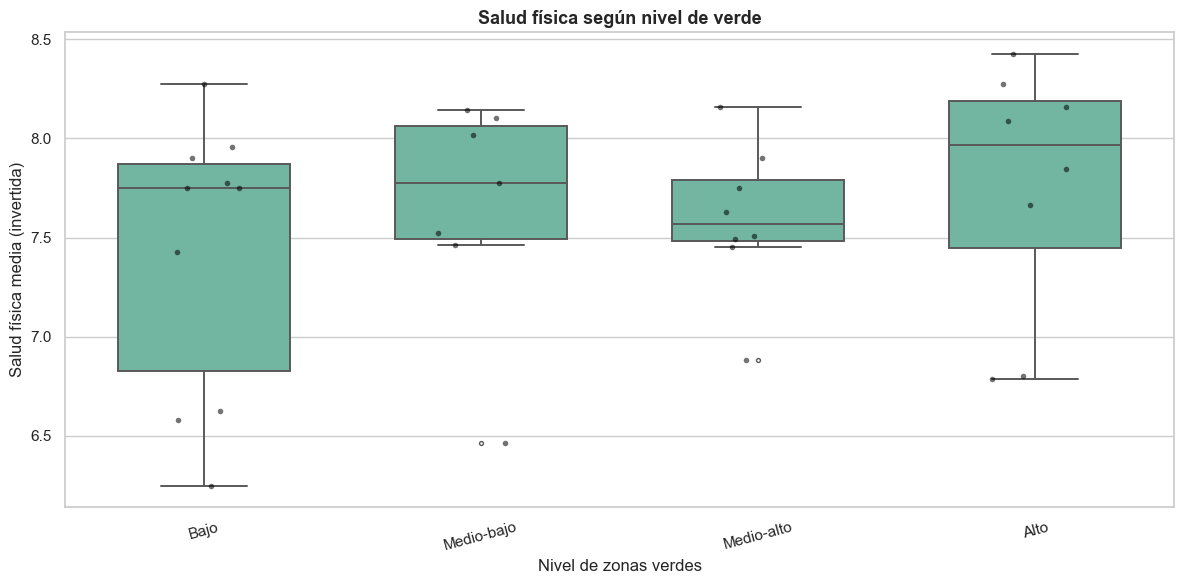

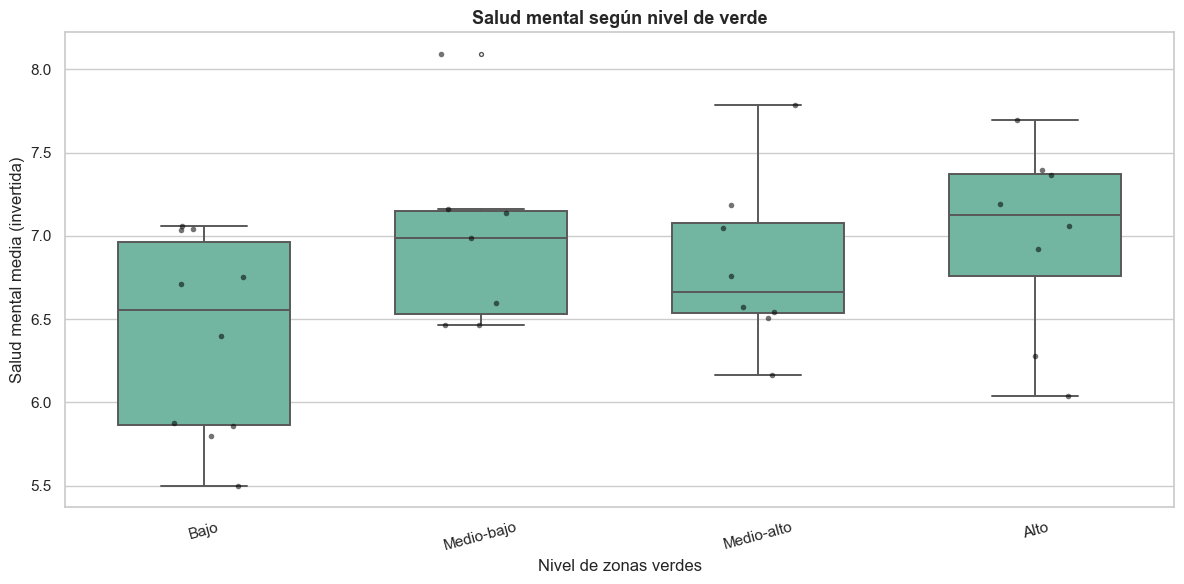

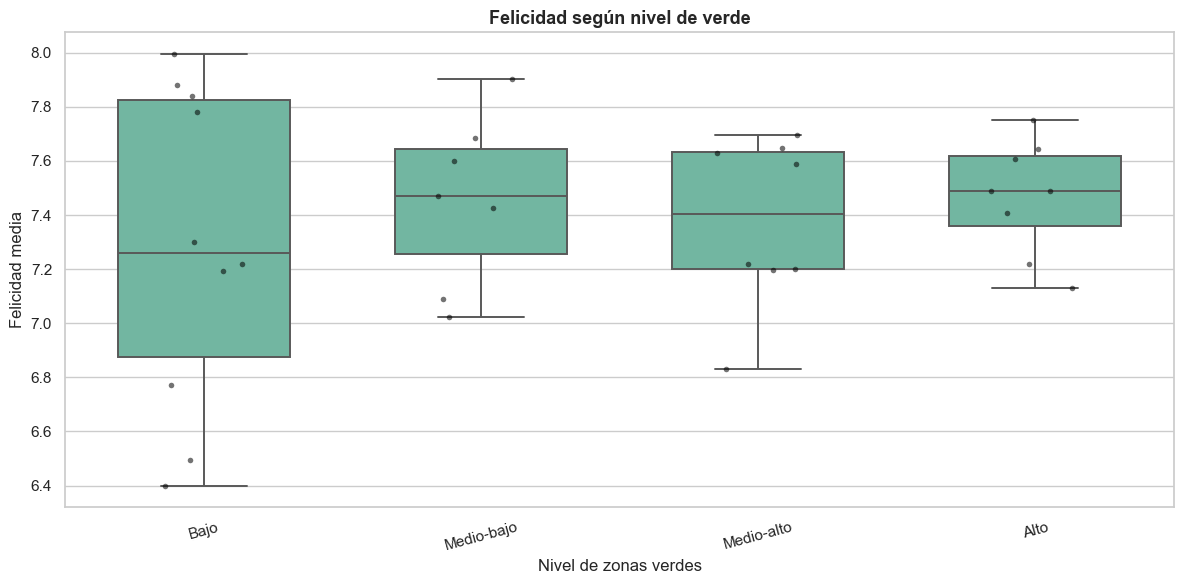

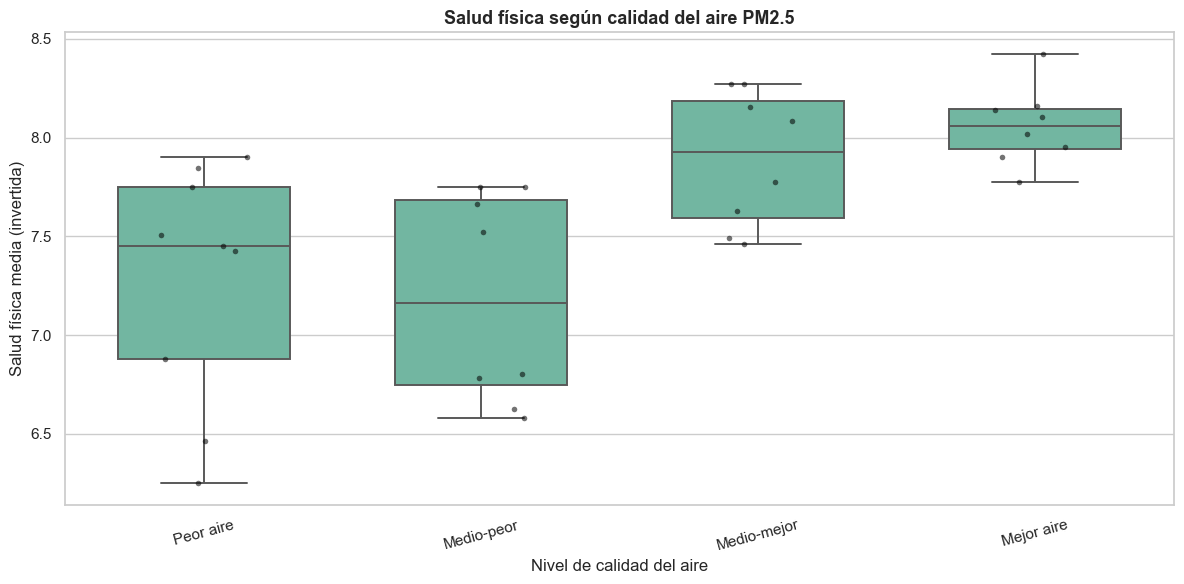

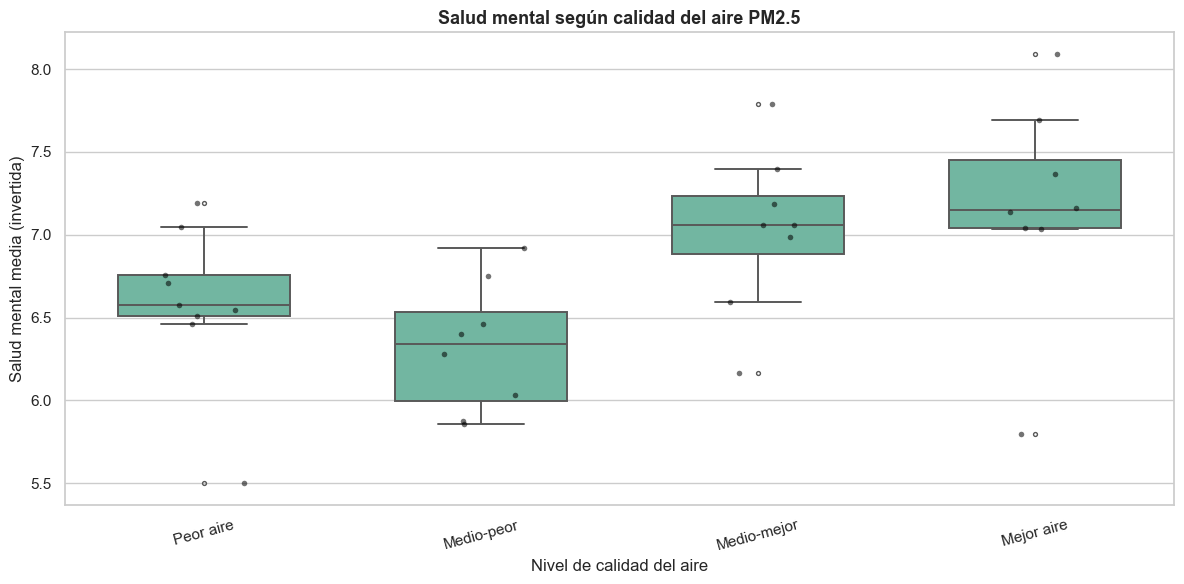

In [186]:
sns.set_theme(style="whitegrid", palette="Set2")

orden_verde = ['Bajo', 'Medio-bajo', 'Medio-alto', 'Alto']
orden_pm25 = ['Peor aire', 'Medio-peor', 'Medio-mejor', 'Mejor aire']
orden_no2 = ['Peor aire', 'Medio-peor', 'Medio-mejor', 'Mejor aire']

# 1. Verde vs Salud física
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=analytic, x='verde_bin', y='salud_fisica_mean_inv10', 
            order=orden_verde, width=0.62, linewidth=1.4, fliersize=2.8, ax=ax)
sns.stripplot(data=analytic, x='verde_bin', y='salud_fisica_mean_inv10', 
              order=orden_verde, color='black', alpha=0.55, size=4, jitter=0.16, ax=ax)
ax.set_title('Salud física según nivel de verde', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de zonas verdes')
ax.set_ylabel('Salud física media (invertida)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# 2. Verde vs Salud mental
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=analytic, x='verde_bin', y='salud_mental_mean_inv10', 
            order=orden_verde, width=0.62, linewidth=1.4, fliersize=2.8, ax=ax)
sns.stripplot(data=analytic, x='verde_bin', y='salud_mental_mean_inv10', 
              order=orden_verde, color='black', alpha=0.55, size=4, jitter=0.16, ax=ax)
ax.set_title('Salud mental según nivel de verde', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de zonas verdes')
ax.set_ylabel('Salud mental media (invertida)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# 3. Verde vs Felicidad
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=analytic, x='verde_bin', y='felicidad_mean_inv10', 
            order=orden_verde, width=0.62, linewidth=1.4, fliersize=2.8, ax=ax)
sns.stripplot(data=analytic, x='verde_bin', y='felicidad_mean_inv10', 
              order=orden_verde, color='black', alpha=0.55, size=4, jitter=0.16, ax=ax)
ax.set_title('Felicidad según nivel de verde', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de zonas verdes')
ax.set_ylabel('Felicidad media')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# 4. PM2.5 vs Salud física
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=analytic, x='pm25_bin', y='salud_fisica_mean_inv10', 
            order=orden_pm25, width=0.62, linewidth=1.4, fliersize=2.8, ax=ax)
sns.stripplot(data=analytic, x='pm25_bin', y='salud_fisica_mean_inv10', 
              order=orden_pm25, color='black', alpha=0.55, size=4, jitter=0.16, ax=ax)
ax.set_title('Salud física según calidad del aire PM2.5', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de calidad del aire')
ax.set_ylabel('Salud física media (invertida)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# 5. PM2.5 vs Salud mental
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=analytic, x='pm25_bin', y='salud_mental_mean_inv10', 
            order=orden_pm25, width=0.62, linewidth=1.4, fliersize=2.8, ax=ax)
sns.stripplot(data=analytic, x='pm25_bin', y='salud_mental_mean_inv10', 
              order=orden_pm25, color='black', alpha=0.55, size=4, jitter=0.16, ax=ax)
ax.set_title('Salud mental según calidad del aire PM2.5', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de calidad del aire')
ax.set_ylabel('Salud mental media (invertida)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

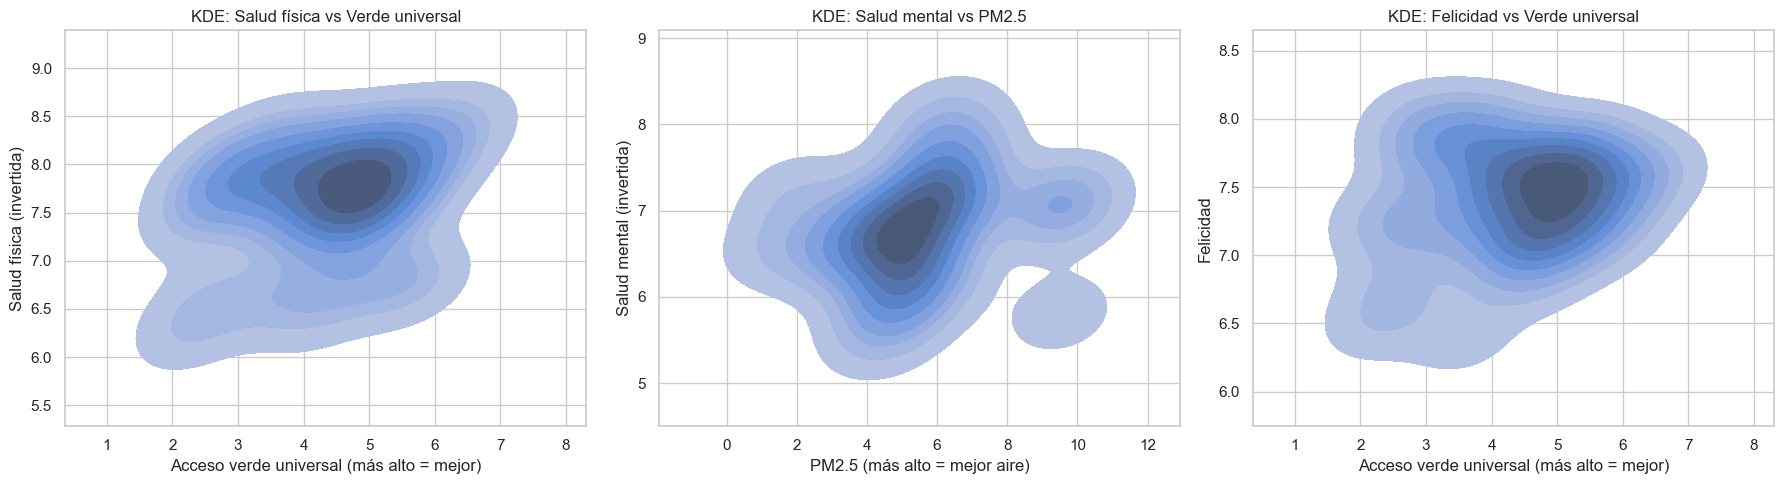

In [187]:


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KDE Salud física vs Verde
sns.kdeplot(data=analytic, x='Universal access to green spaces_rescaled', 
            y='salud_fisica_mean_inv10', fill=True, ax=axes[0])
axes[0].set_title('KDE: Salud física vs Verde universal')
axes[0].set_xlabel('Acceso verde universal (más alto = mejor)')
axes[0].set_ylabel('Salud física (invertida)')

# KDE Salud mental vs PM2.5
sns.kdeplot(data=analytic, x='Air quality (PM2.5)_rescaled', 
            y='salud_mental_mean_inv10', fill=True, ax=axes[1])
axes[1].set_title('KDE: Salud mental vs PM2.5')
axes[1].set_xlabel('PM2.5 (más alto = mejor aire)')
axes[1].set_ylabel('Salud mental (invertida)')

# KDE Felicidad vs Verde
sns.kdeplot(data=analytic, x='Universal access to green spaces_rescaled', 
            y='felicidad_mean_inv10', fill=True, ax=axes[2])
axes[2].set_title('KDE: Felicidad vs Verde universal')
axes[2].set_xlabel('Acceso verde universal (más alto = mejor)')
axes[2].set_ylabel('Felicidad')

plt.tight_layout()
plt.show()

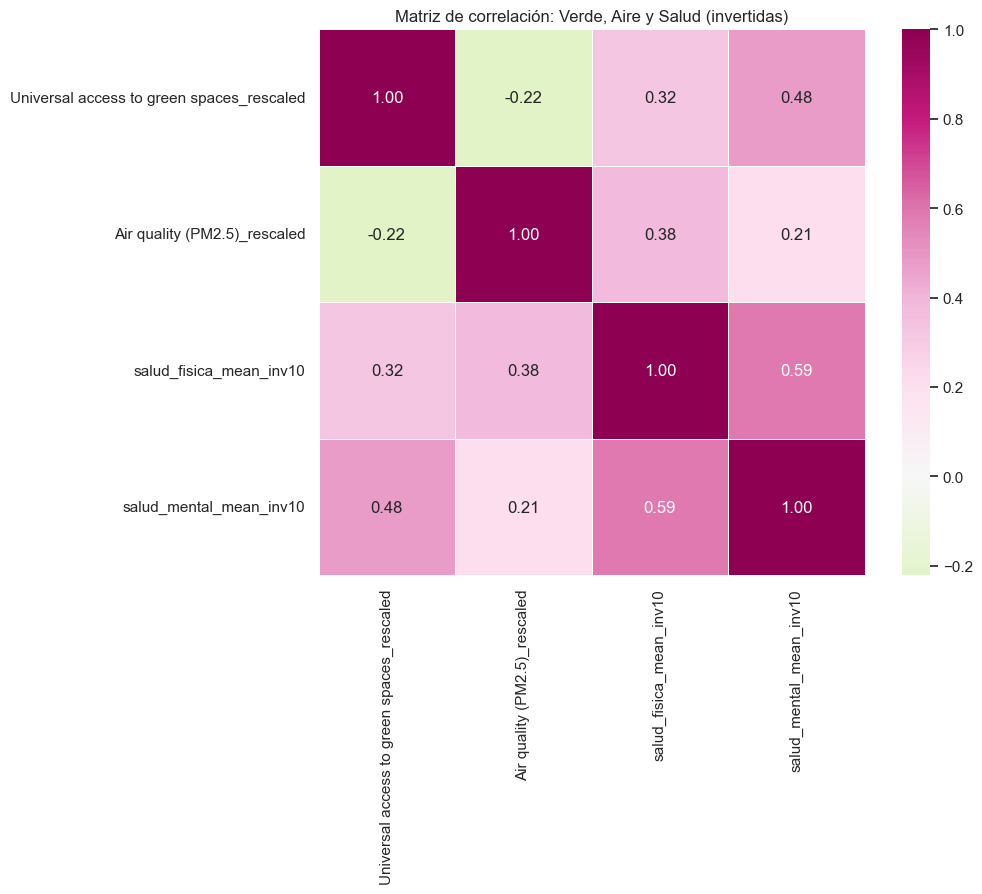

In [202]:
cols_corr = [
    'Universal access to green spaces_rescaled', 
    'Air quality (PM2.5)_rescaled',
    'salud_fisica_mean_inv10',
    'salud_mental_mean_inv10',
]

corr_matrix = analytic[cols_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, cmap='PiYG_r', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación: Verde, Aire y Salud (invertidas)')
plt.tight_layout()
plt.show()

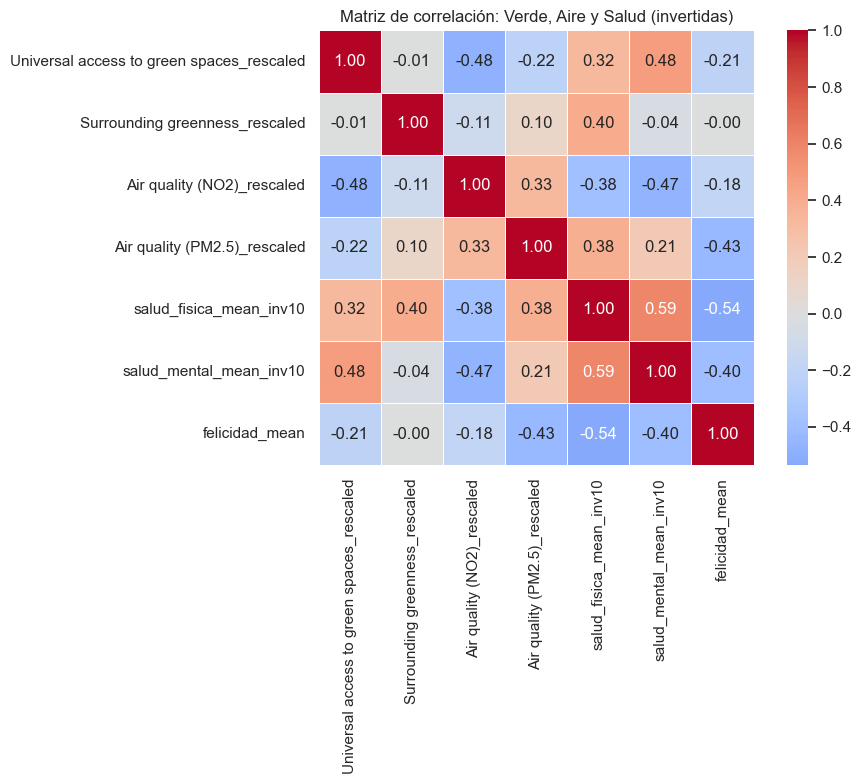

In [ ]:


cols_corr = [
    'Universal access to green spaces_rescaled',
    'Surrounding greenness_rescaled', 
    'Air quality (NO2)_rescaled',
    'Air quality (PM2.5)_rescaled',
    'salud_fisica_mean_inv10',
    'salud_mental_mean_inv10',
    'felicidad_mean'
]

corr_matrix = analytic[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación: Verde, Aire y Salud (invertidas)')
plt.tight_layout()
plt.show()

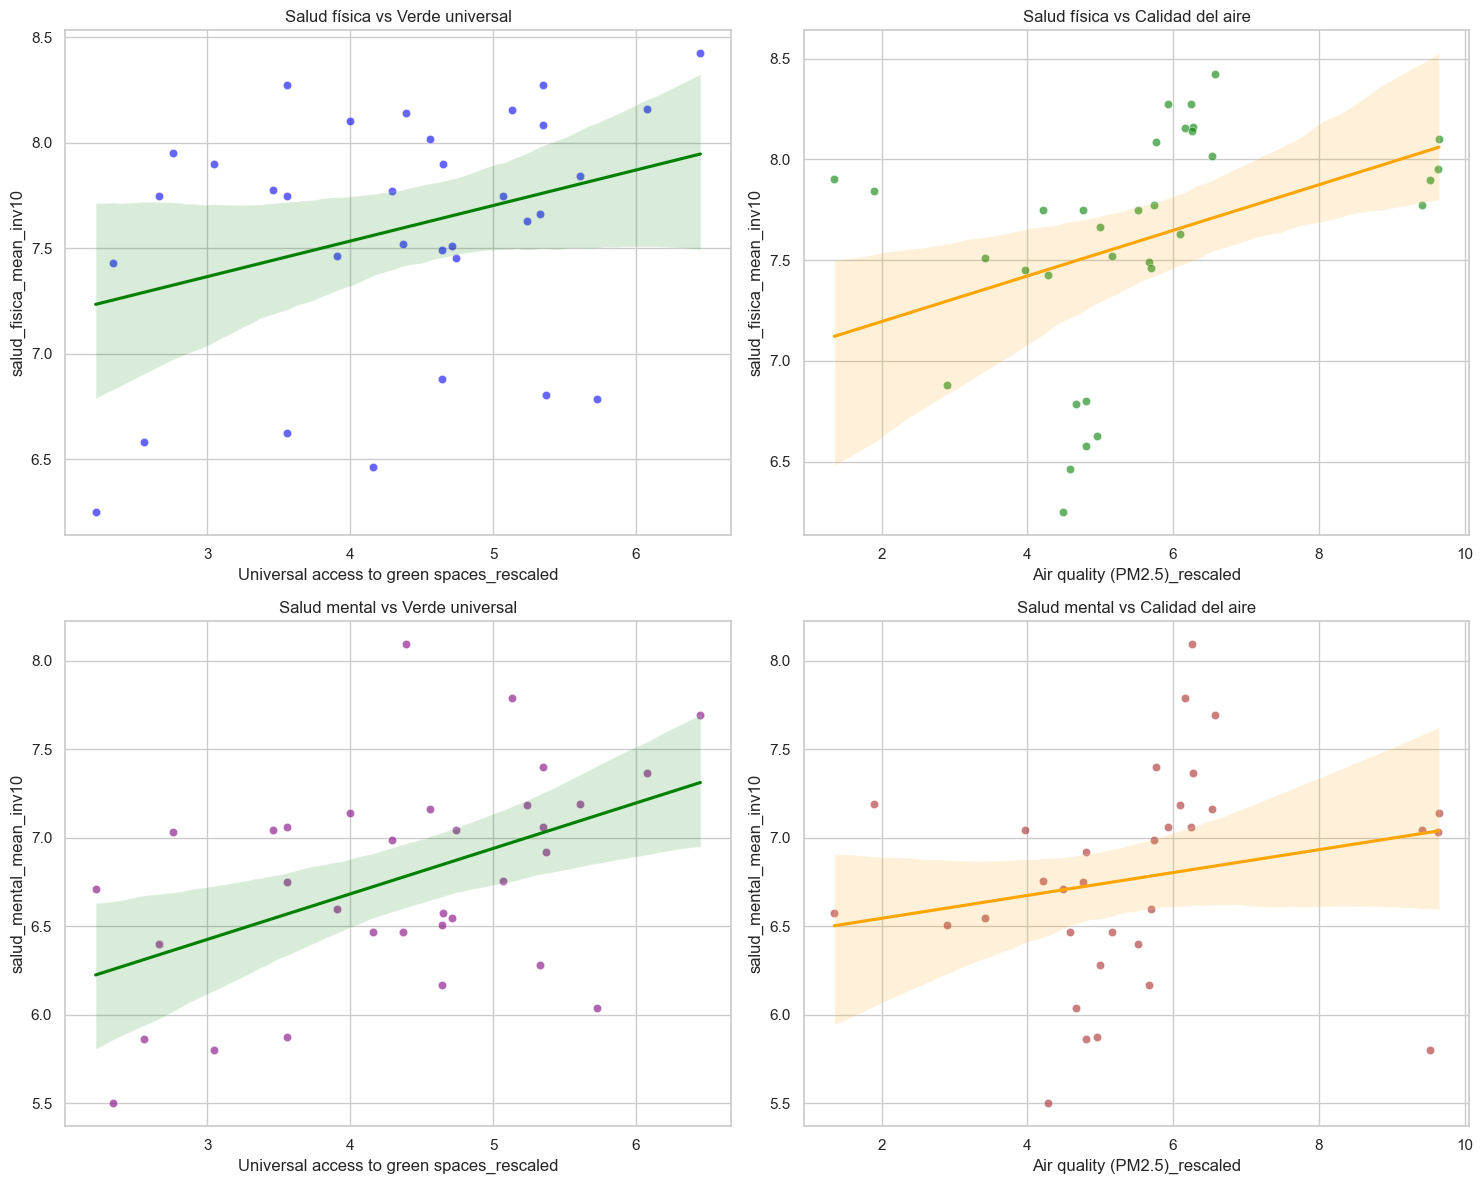

In [200]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Panel 1: Salud física vs Verde (azul puntos, roja línea)
sns.scatterplot(data=analytic, x='Universal access to green spaces_rescaled', 
                y='salud_fisica_mean_inv10', ax=axes[0,0], color='blue', alpha=0.6)
sns.regplot(data=analytic, x='Universal access to green spaces_rescaled', 
            y='salud_fisica_mean_inv10', scatter=False, ax=axes[0,0], 
            color='green')
axes[0,0].set_title('Salud física vs Verde universal')

# Panel 2: Salud física vs Aire (verde puntos, naranja línea)
sns.scatterplot(data=analytic, x='Air quality (PM2.5)_rescaled', 
                y='salud_fisica_mean_inv10', ax=axes[0,1], color='green', alpha=0.6)
sns.regplot(data=analytic, x='Air quality (PM2.5)_rescaled', 
            y='salud_fisica_mean_inv10', scatter=False, ax=axes[0,1], 
            color='orange')
axes[0,1].set_title('Salud física vs Calidad del aire')

# Panel 3: Salud mental vs Verde (púrpura puntos, roja línea)
sns.scatterplot(data=analytic, x='Universal access to green spaces_rescaled', 
                y='salud_mental_mean_inv10', ax=axes[1,0], color='purple', alpha=0.6)
sns.regplot(data=analytic, x='Universal access to green spaces_rescaled', 
            y='salud_mental_mean_inv10', scatter=False, ax=axes[1,0], 
            color='green')
axes[1,0].set_title('Salud mental vs Verde universal')

# Panel 4: Salud mental vs Aire (marrón puntos, naranja línea)
sns.scatterplot(data=analytic, x='Air quality (PM2.5)_rescaled', 
                y='salud_mental_mean_inv10', ax=axes[1,1], color='brown', alpha=0.6)
sns.regplot(data=analytic, x='Air quality (PM2.5)_rescaled', 
            y='salud_mental_mean_inv10', scatter=False, ax=axes[1,1], 
            color='orange')
axes[1,1].set_title('Salud mental vs Calidad del aire')

plt.tight_layout()
plt.show()

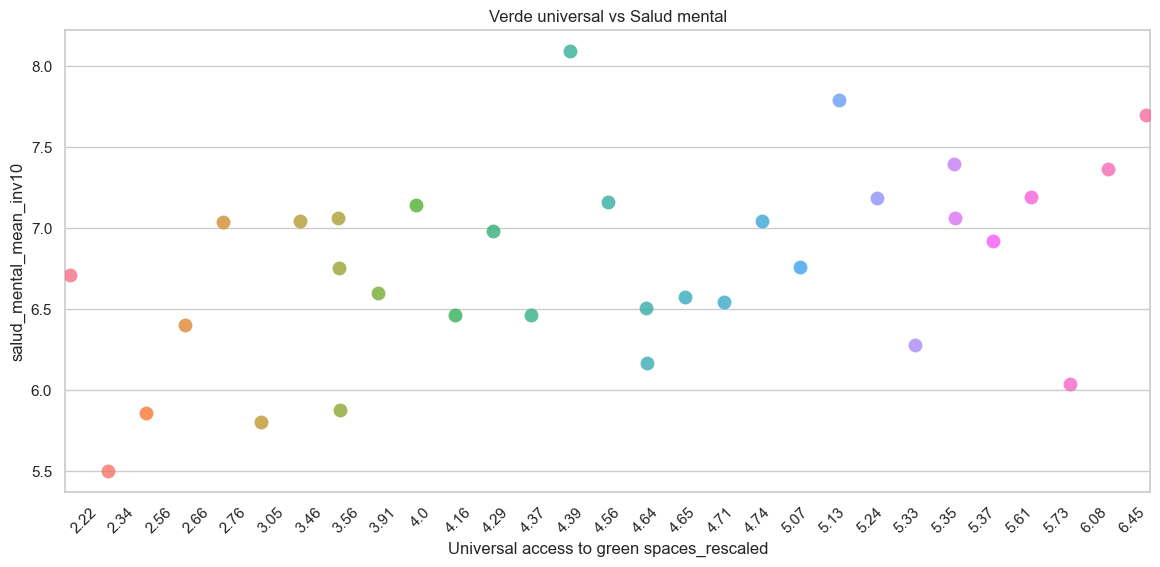

In [191]:
plt.figure(figsize=(14, 6))
sns.stripplot(data=analytic, x='Universal access to green spaces_rescaled', 
              y='salud_mental_mean_inv10', hue='city_clean', dodge=0.4, size=10, alpha=0.8, legend=False)
plt.title('Verde universal vs Salud mental')
plt.xticks(rotation=45); plt.show()

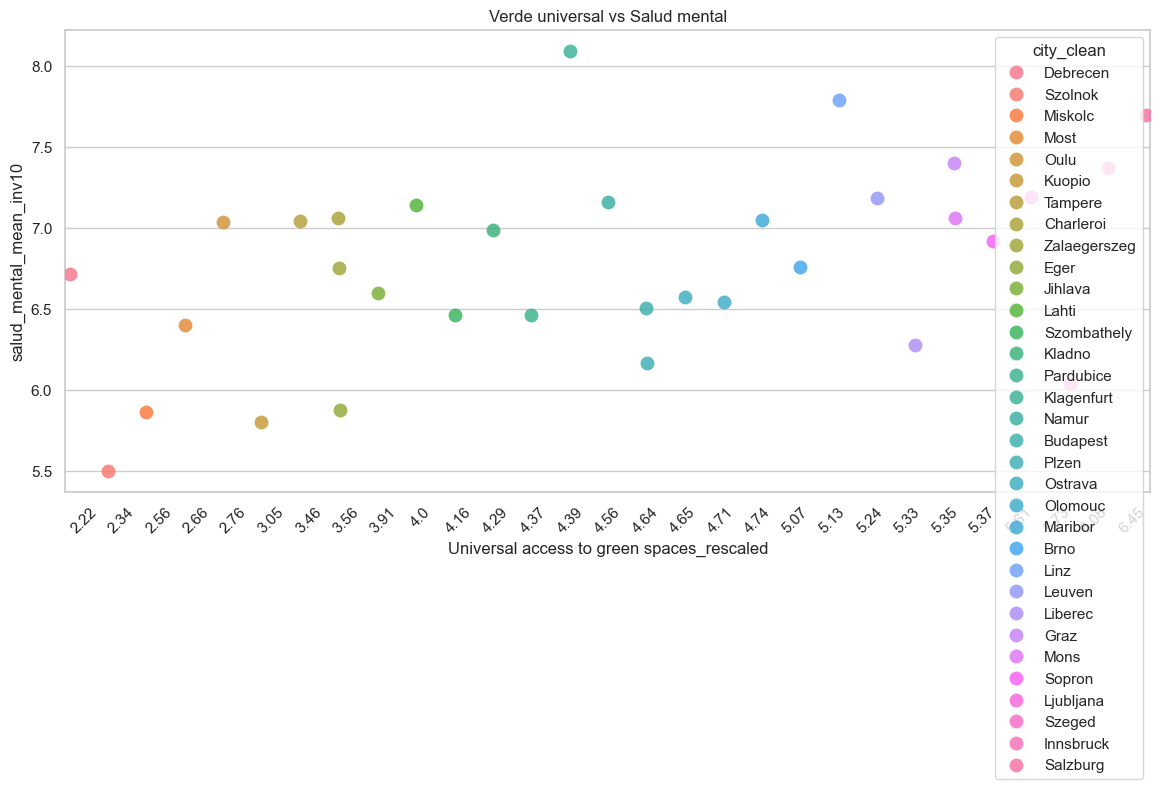

In [197]:
plt.figure(figsize=(14, 6))
sns.stripplot(data=analytic, x='Universal access to green spaces_rescaled', 
              y='salud_mental_mean_inv10', hue='city_clean', dodge=0.4, size=10, alpha=0.8, legend=True)
plt.title('Verde universal vs Salud mental')
plt.xticks(rotation=45); plt.show()

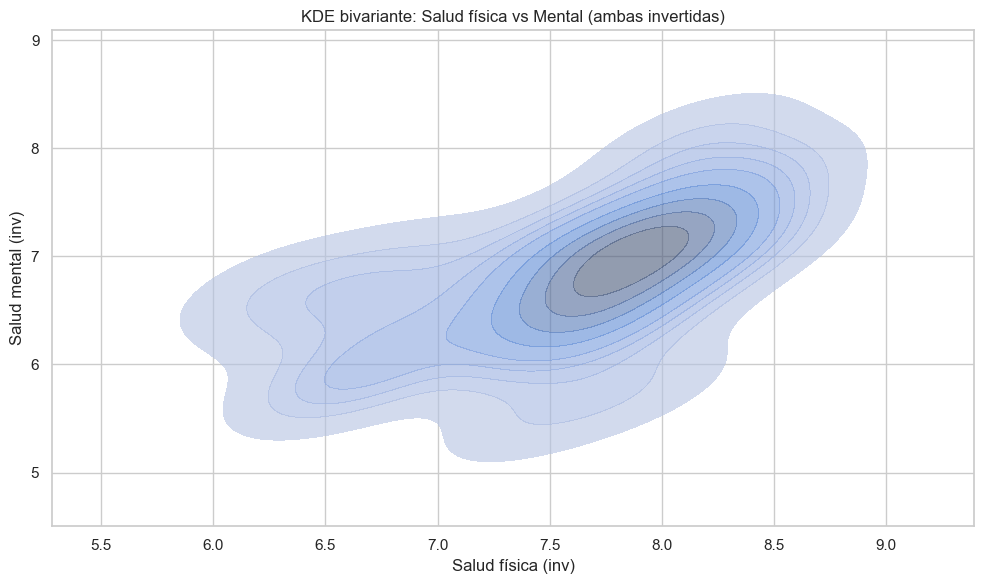

In [192]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=analytic, x='salud_fisica_mean_inv10', 
            y='salud_mental_mean_inv10', fill=True, alpha=0.6, ax=ax)
ax.set_title('KDE bivariante: Salud física vs Mental (ambas invertidas)')
ax.set_xlabel('Salud física (inv)')
ax.set_ylabel('Salud mental (inv)')
plt.tight_layout()
plt.show()

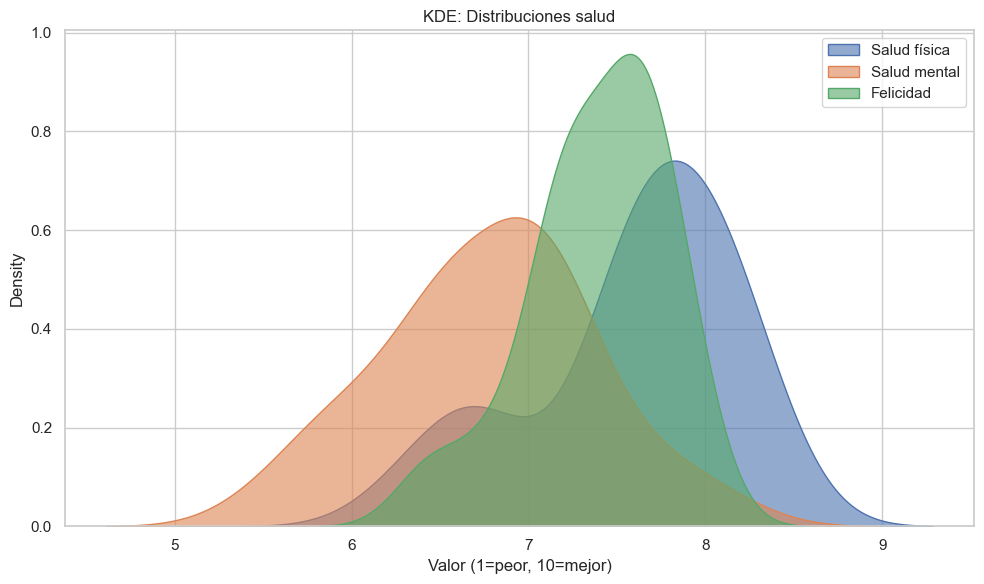

In [203]:

fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(data=analytic, x='salud_fisica_mean_inv10', 
            fill=True, alpha=0.6, label='Salud física', ax=ax)
sns.kdeplot(data=analytic, x='salud_mental_mean_inv10', 
            fill=True, alpha=0.6, label='Salud mental', ax=ax)
sns.kdeplot(data=analytic, x='felicidad_mean_inv10', 
            fill=True, alpha=0.6, label='Felicidad', ax=ax)

ax.set_title('KDE: Distribuciones salud')
ax.set_xlabel('Valor (1=peor, 10=mejor)')
ax.legend()
plt.tight_layout()
plt.show()

In [194]:
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt

salud_cols = ['salud_fisica_mean_inv10', 'salud_mental_mean_inv10', 'felicidad_mean_inv10']
verde_cols = ['Universal access to green spaces_rescaled']
aire_cols = ['Air quality (PM2.5)_rescaled']

resultados = []

# Spearman salud vs verde
for s in salud_cols:
    for v in verde_cols:
        subset = analytic[[s, v]].dropna()
        rho, p = spearmanr(subset[s], subset[v])
        resultados.append({
            'Variable_salud': s,
            'Variable_ambiental': v,
            'rho_Spearman': rho,
            'p_valor': p,
            'n_obs': len(subset)
        })
        print(f"{s} vs {v}: rho = {rho:.3f}, p = {p:.4f} (n={len(subset)})")

# Spearman salud vs aire (PM2.5)
for s in salud_cols:
    for a in aire_cols:
        subset = analytic[[s, a]].dropna()
        rho, p = spearmanr(subset[s], subset[a])
        resultados.append({
            'Variable_salud': s,
            'Variable_ambiental': a,
            'rho_Spearman': rho,
            'p_valor': p,
            'n_obs': len(subset)
        })
        print(f"{s} vs {a}: rho = {rho:.3f}, p = {p:.4f} (n={len(subset)})")

pd.DataFrame(resultados)


salud_fisica_mean_inv10 vs Universal access to green spaces_rescaled: rho = 0.293, p = 0.0984 (n=33)
salud_mental_mean_inv10 vs Universal access to green spaces_rescaled: rho = 0.466, p = 0.0063 (n=33)
felicidad_mean_inv10 vs Universal access to green spaces_rescaled: rho = 0.096, p = 0.5942 (n=33)
salud_fisica_mean_inv10 vs Air quality (PM2.5)_rescaled: rho = 0.636, p = 0.0001 (n=33)
salud_mental_mean_inv10 vs Air quality (PM2.5)_rescaled: rho = 0.430, p = 0.0126 (n=33)
felicidad_mean_inv10 vs Air quality (PM2.5)_rescaled: rho = 0.381, p = 0.0288 (n=33)


,Variable_salud,Variable_ambiental,rho_Spearman,p_valor,n_obs
0,salud_fisica_mean_inv10,Universal access to green spaces_rescaled,0.292632,0.098407,33
1,salud_mental_mean_inv10,Universal access to green spaces_rescaled,0.465970,0.006275,33
2,felicidad_mean_inv10,Universal access to green spaces_rescaled,0.096229,0.594227,33
3,salud_fisica_mean_inv10,Air quality (PM2.5)_rescaled,0.636462,0.000068,33
4,salud_mental_mean_inv10,Air quality (PM2.5)_rescaled,0.429550,0.012605,33
5,felicidad_mean_inv10,Air quality (PM2.5)_rescaled,0.380881,0.028757,33


Para contrastar mis hipótesis, calculé la correlación de Spearman entre los indicadores de salud/felicidad invertidos a escala 0-10 (salud_fisica_mean_inv10, salud_mental_mean_inv10, felicidad_mean_inv10) y las variables ambientales rescaled de ISGlobal (Universal access to green spaces_rescaled y Air quality (PM2.5)_rescaled). Elegí Spearman porque es no paramétrica, mide relaciones monótonas y es robusta a outliers, común en datos agregados por región. Un ρ negativo indica que mayor acceso a verde se asocia con mejor salud/felicidad. En especial es así para la salud mental y el acceso a zonas verdes con un p valor de 0.006275. También a destacar el p valor de salud física y calidad del aire. 

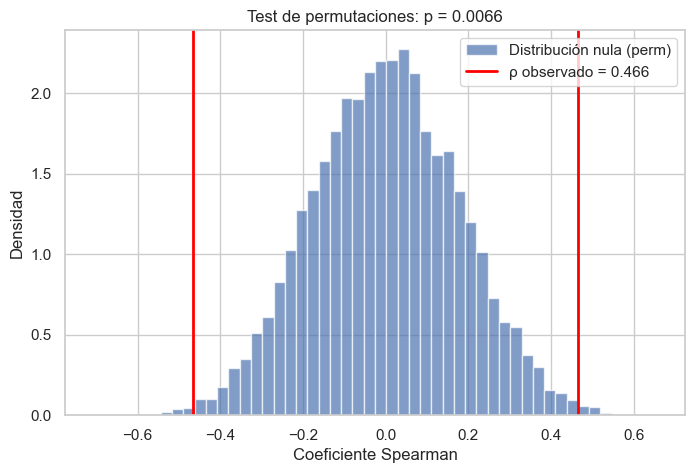

p observado: 0.466, p-permutación: 0.0066


In [195]:

def test_permutacion_spearman(x, y, n_perm=10000):
   
    # Spearman observado
    rho_obs, _ = spearmanr(x, y)
    
    # Generar distribución nula
    rhos_perm = np.zeros(n_perm)
    for i in range(n_perm):
        y_perm = np.random.permutation(y)
        rhos_perm[i], _ = spearmanr(x, y_perm)
    
    # p-valor: proporción de |rho_perm| >= |rho_obs|
    p_perm = (np.abs(rhos_perm) >= np.abs(rho_obs)).mean()
    
    plt.figure(figsize=(8,5))
    plt.hist(rhos_perm, bins=50, alpha=0.7, density=True, label='Distribución nula (perm)')
    plt.axvline(rho_obs, color='red', lw=2, label=f'ρ observado = {rho_obs:.3f}')
    plt.axvline(-rho_obs, color='red', lw=2)
    plt.xlabel('Coeficiente Spearman')
    plt.ylabel('Densidad')
    plt.title(f'Test de permutaciones: p = {p_perm:.4f}')
    plt.legend()
    plt.show()
    
    return rho_obs, p_perm

x = analytic['salud_mental_mean_inv10'].dropna()
y = analytic['Universal access to green spaces_rescaled'].loc[x.index] 

rho_obs, p_perm = test_permutacion_spearman(x, y)
print(f"p observado: {rho_obs:.3f}, p-permutación: {p_perm:.4f}")

Para validar la significancia de forma no paramétrica y sin supuestos distribucionales adicionales, implementé un test de permutaciones. Generé 10.000 permutaciones del vector de verde (rompiendo su asociación con salud), calculé Spearman en cada una, y obtuve la distribución nula de 𝜌.

Calculé el coeficiente de Spearman entre salud_mental_mean_inv10 y Universal access to green spaces_rescaled, obteniendo ρ=0.466 (correlación monótona moderada) con p-valor < 0.05.

Validé con un test de permutaciones (10.000 repeticiones): bajo H0 de independencia, permuté aleatoriamente Universal access... y recalculé Spearman cada vez, generando la distribución nula exacta {ρi}. 
El p-valor p=Pr(∣ρi∣≥0.466)=0.0074 confirma significancia (rechazo H0), siendo más robusto que la aproximación paramétrica de Spearman al no asumir normalidad asintótica.

Los resultados confirman la correlacion entre salud mental y acceso a zonas verdes, coincidiendo con el p-valor de Spearman.

Ambos métodos coinciden en rechazar 𝐻0 (p < 0.05), pero el test de permutaciones es preferible aquí: genera la distribución nula exacta de Spearman para mis datos específicos (𝑛≈30–500), sin aproximaciones asintóticas. El p=0.0074 es más conservador y robusto a no-normalidad, confirmando una asociación monótona significativa entre acceso a verde y mejor salud mental percibida."


### Impacto potencial:  
Priorizar inversiones en verde y calidad del aire donde la salud autopercibida es peor.
Inversiones por parte de las empresas en naturaleza puede repercutir enormemente en la salud de sus empleados, y en la felicidad de los mismos, aumentando su productividad.